## Setup

Project root detection, imports, and global configuration.

In [1]:
# --- Project root setup (run first) ---
from pathlib import Path
import os, sys  # noqa

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "requirements.txt").exists():
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root = {project_root}")

Project root = C:\Users\aurel\Desktop\M2\Stage ecoseas-csm\CSM\bcw-paper-2025


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import json
import warnings

from colorama import Fore, Style
from matplotlib.colors import ListedColormap

from src.config import (
    CMOL, ISO_MAP1, CONTINENT_MAP1, ISO_OVERRIDES1, DATA_DIR,
    OUTPUT_DIR, SUMMARY_DIR, WLD_SHP, USA_SPLIT_CSV, EEZ_SHP,
    MAPPING_JSON,
)
from src.visualization import (
    complete_iso_and_continent, build_world_geodataframe, 
    format_log_axis_plain, circle_area_plot, regplotter, 
    map_and_barplot, wind_rose, stats_for_group,
    plot_eez_choropleth, smart_annotate,
    CONTINENT_PAL, BCE_COLORMAP, BCP_COLORMAP, GROUPS_COLORMAP,
)

In [3]:
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.options.display.max_rows = 500
pd.options.display.max_columns = 40
sns.set_style("whitegrid")

blueprint  = Fore.BLUE
redprint   = Fore.RED
greenprint = Fore.GREEN
reset      = Style.RESET_ALL

In [4]:
# --- Data loading ---

# GSCC distribution
npz = np.load(OUTPUT_DIR / "draws.npz", allow_pickle=True)
gscc_dist = npz['gscc_draws']
gscc_value = np.mean(gscc_dist) if len(gscc_dist) > 0 else np.nan
print(f"{greenprint}Global Social Cost of Carbon (GSCC): {gscc_value:.2f} US$/tCO2{reset}")

# Country-name → world-geometry mapping
mapping = json.load(open(MAPPING_JSON, encoding='utf8'))

# Unadjusted BCW dataset (for EEZ choropleth cells)
bcw = pd.read_csv(SUMMARY_DIR / 'unadjusted_bcw_data.csv')

# Adjusted country-level BCW dataset (main analysis table)
data = pd.read_csv(OUTPUT_DIR / 'country_level_bcw.csv')
data['cBCW_per_capita'] = data['cBCW'] / data['Population']
data['oBCW_per_capita'] = data['oBCW'] / data['Population']

Global Social Cost of Carbon (GSCC): 559.57 US$/tCO2


In [5]:
# --- Palettes ---
pal        = CONTINENT_PAL
color_map2 = BCE_COLORMAP
color_map3 = BCP_COLORMAP
color_mapping = GROUPS_COLORMAP

# --- ISO/Continent completion for EEZ map cells ---
plot_data = complete_iso_and_continent(
    bcw,
    iso_map=ISO_MAP1,
    continent_map=CONTINENT_MAP1,
    overrides=ISO_OVERRIDES1,
)

# --- World geometry ---
world = build_world_geodataframe(WLD_SHP, USA_SPLIT_CSV)
wld   = world  # alias used by mapper cells

# --- Legacy df aliases ---
ddf = data.copy()
ddf['Total_BCE_area_km2'] = ddf[
    ['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
].sum(axis=1, skipna=True)

# --- Cubehelix colormap (for blue carbon stocks map) ---
palet = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)

In [6]:
# --- Sequestration table (needed by paper2 pie charts and paper3 circle plot) ---
sdf = data.copy()
sdf.rename(columns={
    'Area_EEZ_KM2': 'EEZ Area (km²)',
    'saltmarshes_area_km2': 'Saltmarshes Area (km²)',
    'seagrasses_area_km2': 'Seagrasses Area (km²)',
    'mangroves_area_km2': 'Mangroves Area (km²)',
    'uptake_salt_mean': 'Saltmarshes Sequestration (tC)',
    'uptake_seag_mean': 'Seagrasses Sequestration (tC)',
    'uptake_mang_mean': 'Mangroves Sequestration (tC)',
    'uptake_total_mean': 'Total BCEs Sequestration (tC)',
    'BCP Seq (tC)': 'BCP Sequestration (tC)',
    'Total BCseq': 'Total Blue Carbon Sequestration (tC)',
}, inplace=True)

# Continental aggregates used by paper2 pie charts
bd = sdf.groupby('Continent')[[
    'Saltmarshes Sequestration (tC)', 'Seagrasses Sequestration (tC)',
    'Mangroves Sequestration (tC)', 'Total BCEs Sequestration (tC)',
    'BCP Sequestration (tC)', 'Total Blue Carbon Sequestration (tC)'
]].sum().reset_index()
bd = bd.sort_values(by='Total Blue Carbon Sequestration (tC)', ascending=False)

# Ecosystem totals used by paper3 circle plot
seqt = ddf[[
    'ISO', 'Continent', 'Groups', 'uptake_salt_mean', 'uptake_seag_mean',
    'uptake_mang_mean', 'BCP Seq (tC)'
]].copy().rename(columns={
    'uptake_salt_mean': 'Saltmarshes Sequestration (tC)',
    'uptake_seag_mean': 'Seagrasses Sequestration (tC)',
    'uptake_mang_mean': 'Mangroves Sequestration (tC)',
    'BCP Seq (tC)': 'BCP Sequestration (tC)',
})
ecosystem_totals = seqt.select_dtypes(include='number').sum() / 1e6
ecosystem_totals = ecosystem_totals.sort_values(ascending=False)

In [7]:
# --- EEZ per-capita top-30 (needed by paper1) ---
by_eez = data[['country_name', 'ISO', 'Groups', 'Area_EEZ_KM2', 'Population']].copy()
by_eez['Area_EEZ_KM2_per_capita'] = by_eez['Area_EEZ_KM2'] / by_eez['Population']
by_eez_sorted = by_eez.sort_values(by='Area_EEZ_KM2_per_capita', ascending=False)
top_30_eez = by_eez_sorted.head(30)

# --- BCW finance indicators (needed by paper7) ---
selection = [
    "ISO", "country_name", "Continent", "Groups",
    "Population", "GDP", "Debt (2015 US$)", "CO2_emissions_2023",
    "uptake_total_mean", "BCP Seq (tC)",
    "cBCW", "Total BCW"
]
df = data[selection].copy()

df["S_BCE"]     = df["uptake_total_mean"] * CMOL
df["S_BCE_BCP"] = df["BCP Seq (tC)"] * CMOL
df["S_ALL"]     = df["S_BCE"] + df["S_BCE_BCP"]
df["E"]         = df["CO2_emissions_2023"]

df["NetCO2_BCE"]   = df["S_BCE"] - df["E"]
df["NetCO2_ALL"]   = df["S_ALL"] - df["E"]
df["Delta_NetCO2"] = df["NetCO2_ALL"] - df["NetCO2_BCE"]

df["is_net_sink_BCE"]  = df["NetCO2_BCE"] < 0
df["is_net_sink_ALL"]  = df["NetCO2_ALL"] < 0
df["switch_sink_status"] = df["is_net_sink_ALL"] != df["is_net_sink_BCE"]

df["Coverage_BCE"] = df["cBCW"]      / (df["E"] * gscc_value)
df["Coverage_ALL"] = df["Total BCW"] / (df["E"] * gscc_value)
df["Delta_Coverage"] = df["Coverage_ALL"] - df["Coverage_BCE"]

df["Relief_BCE"]   = (df["S_BCE"] * gscc_value) / df["Debt (2015 US$)"]
df["Relief_ALL"]   = (df["S_ALL"] * gscc_value) / df["Debt (2015 US$)"]
df["Delta_Relief"] = df["Relief_ALL"] - df["Relief_BCE"]

df["Debt_to_GDP"]   = df["Debt (2015 US$)"] / df["GDP"]
thr = df["Debt_to_GDP"].median(skipna=True)
df["high_debt_stress"] = df["Debt_to_GDP"] >= thr

def quadrant(is_sink, high_stress):
    if (not is_sink) and high_stress:  return "Source + high debt stress"
    if (not is_sink) and (not high_stress): return "Source + low debt stress"
    if is_sink and high_stress:         return "Sink + high debt stress"
    return "Sink + low debt stress"

df["Quadrant_BCE"]  = [quadrant(s, h) for s, h in zip(df["is_net_sink_BCE"], df["high_debt_stress"])]
df["Quadrant_ALL"]  = [quadrant(s, h) for s, h in zip(df["is_net_sink_ALL"], df["high_debt_stress"])]
df["switch_quadrant"] = df["Quadrant_BCE"] != df["Quadrant_ALL"]

top_delta_cov    = df.sort_values("Delta_Coverage", ascending=False).head(25)
top_delta_relief = df.sort_values("Delta_Relief",   ascending=False).head(25)
print("Setup complete.")

Setup complete.


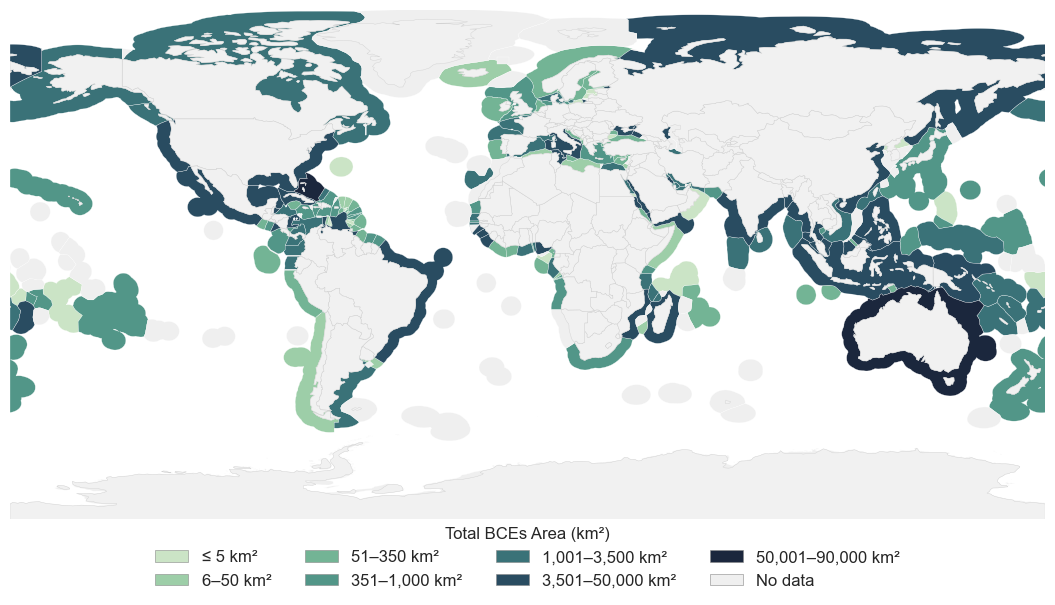

In [8]:
# paper1
# EEZ file    : EEZ_land_union_v4_202410.shp  (data_source/shp/eez/)
# Join column : TERRITORY1  (present in plot_data)

# Build input: total BCE area per EEZ territory
map_df = plot_data[
    ['country_name', 'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
].copy()
map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
map_df['Total BCEs Area (km²)'] = (
    map_df[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']]
    .sum(axis=1, skipna=True)
).replace(0, np.nan)

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=map_df,
    value_col='Total BCEs Area (km²)',
    merge_on='UNION',
    world_gdf=WLD_SHP,
    bins=[-1, 5, 50, 350, 1000, 3500, 50000, 90000],
    palette='cubehelix',
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    figsize=(14, 6),
    title='',
    dissolve_by=None,
    clip_land=True,
 )
plt.show()

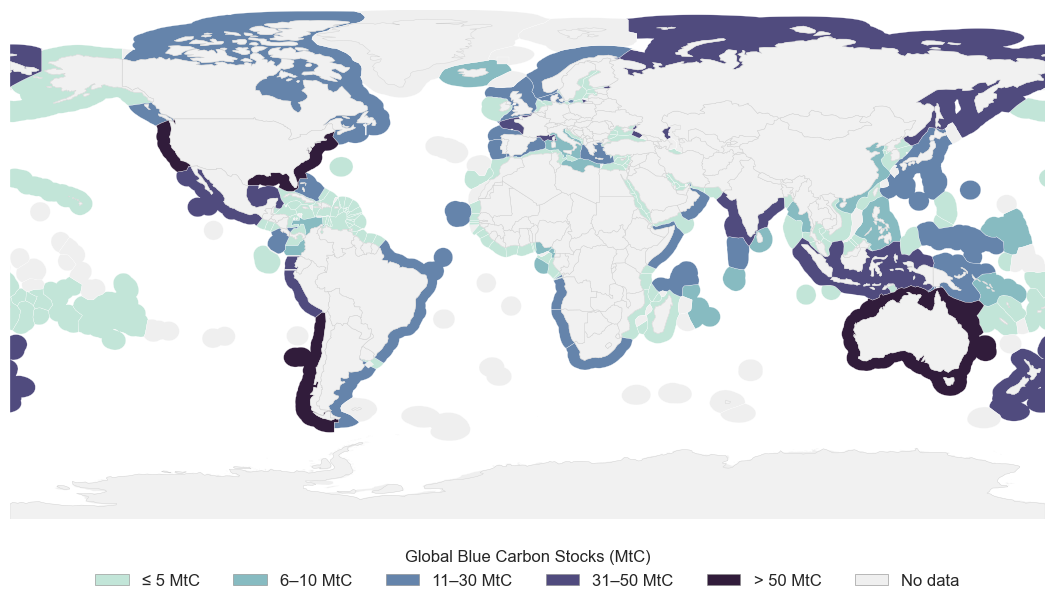

In [9]:
# paper1
map_df = plot_data[
    ['country_name', 'Total BCseq']
].copy()
map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
map_df['Global Blue Carbon Stocks (MtC)'] = map_df['Total BCseq'] / 1e6  # convert to MtC

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=map_df,
    value_col='Global Blue Carbon Stocks (MtC)',
    merge_on='UNION',
    world_gdf=WLD_SHP,
    bins=[-1, 5, 10, 30, 50],
    units='MtC',
    palette=palet,
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    legend_ncol=6,
    figsize=(14, 6),
    title='',
    dissolve_by=None,
    clip_land=True,
)
plt.show()

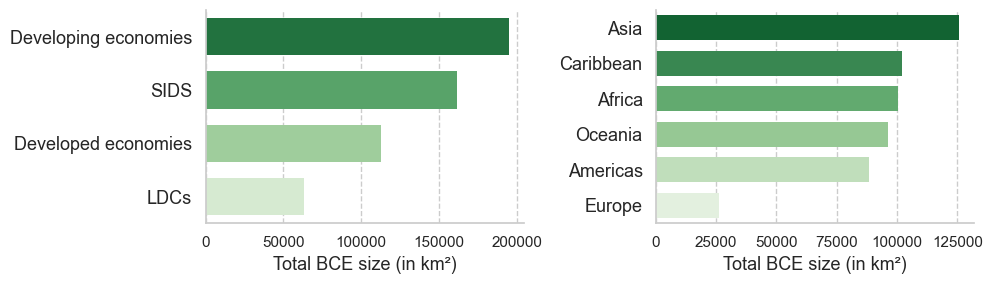

In [47]:
# paper1
grou = ddf.groupby('Groups')['Total_BCE_area_km2'].sum().sort_values(ascending=False).reset_index()
grou['Total_BCE_area_km2'] = grou['Total_BCE_area_km2']

grou2 = ddf.groupby('Continent')['Total_BCE_area_km2'].sum().sort_values(ascending=False).reset_index()
grou2['Total_BCE_area_km2'] = grou2['Total_BCE_area_km2']

# on 1 row and 2 cols
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
sns.set_theme(style='whitegrid')
# Groups
sns.barplot(
    data=grou, x='Total_BCE_area_km2', y='Groups', 
    width=0.7, palette='Greens_r', ax=axs[0], edgecolor='none'
)
axs[0].set_ylabel('')
axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=13)
axs[0].set_xlabel('Total BCE size (in km²)', fontsize=13)
sns.despine(ax=axs[0])
axs[0].grid(True, axis='x', linestyle='--')

# Continents
sns.barplot(
    data=grou2, x='Total_BCE_area_km2', y='Continent', 
    width=0.7, palette='Greens_r', ax=axs[1], edgecolor='none'
)
axs[1].set_ylabel('')
axs[1].set_yticklabels(axs[1].get_yticklabels(), fontsize=13)
axs[1].set_xlabel('Total BCE size (in km²)', fontsize=13)
sns.despine(ax=axs[1])
axs[1].grid(True, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

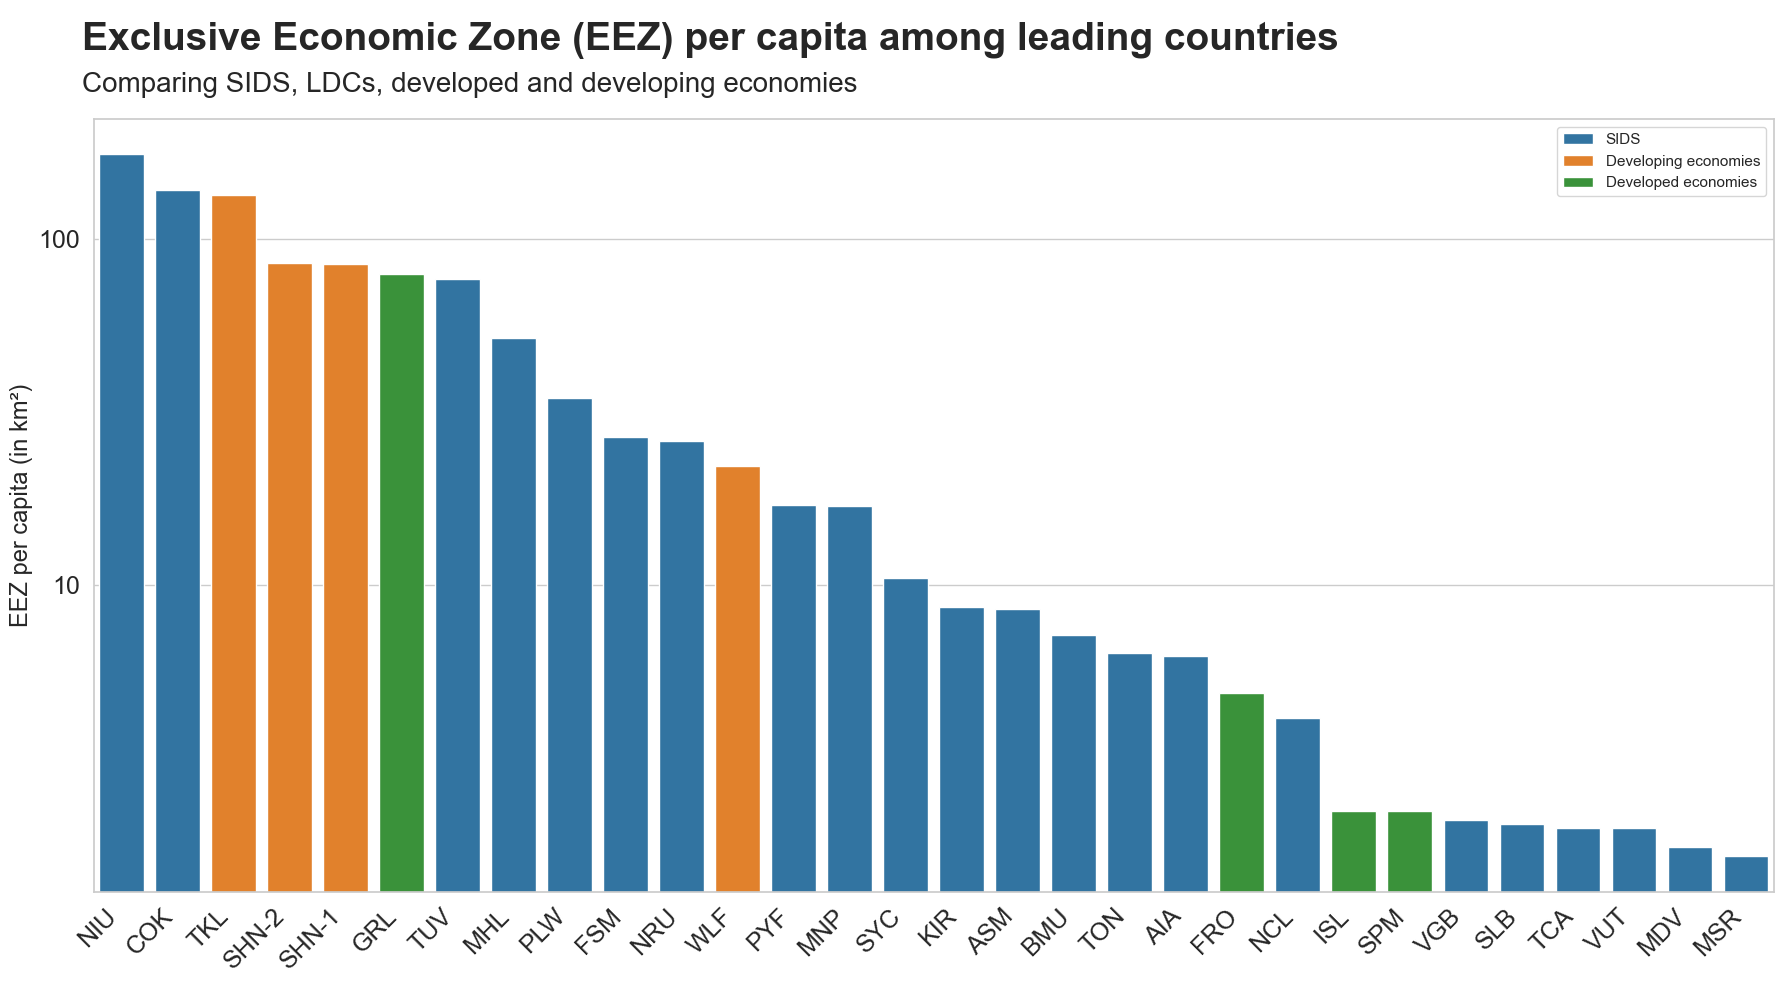

In [11]:
# paper1
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(top_30_eez, x='ISO', y='Area_EEZ_KM2_per_capita', palette= 'tab10', ci=False, hue='Groups',ax=ax)
fig.text(0.05, 0.97, 'Exclusive Economic Zone (EEZ) per capita among leading countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.05, 0.92, 'Comparing SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')

# fig.text(0.045, 0, 'Note: The suffixes added to ISO codes, such as SHN-1, SHN-2, SHN-3 for Saint Helena, Ascension, and Tristan Da Cunha, and KIR-1 for the Gilbert Islands, KIR-2 for the Phoenix Islands, and KIR-3 for the Line Islands of Kiribati, are used to differentiate these territories under the same ISO designation.', 
#          fontsize=18, va='top', ha='left', wrap=True)

plt.title('d', color='white', pad=70)
plt.ylabel('EEZ per capita (in km²)', fontsize=17)
plt.xlabel('')
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.legend()
plt.show()

Pie chart of Total Blue Carbon Sequestration by Continent:


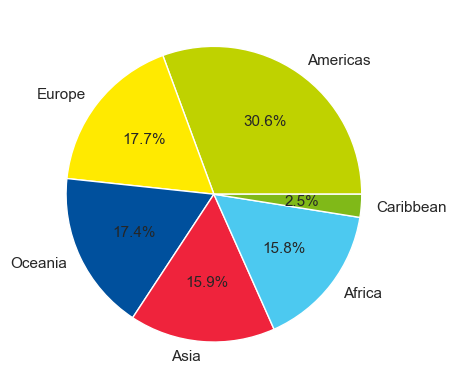

Pie chart of Total BCEs Sequestration by Continent:


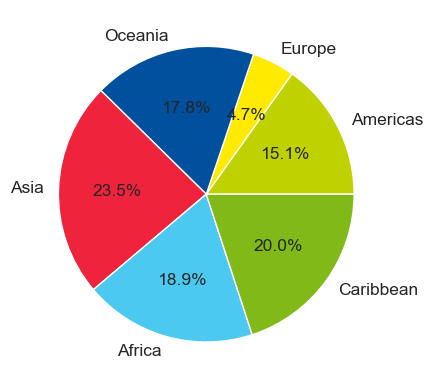

In [12]:
# paper2
colors = [pal[continent] for continent in bd['Continent']]
print("Pie chart of Total Blue Carbon Sequestration by Continent:")
plt.pie(bd['Total Blue Carbon Sequestration (tC)'], colors=colors, labels=bd['Continent'], 
        autopct='%1.1f%%', textprops={'fontsize': 11})
plt.show()

colors = [pal[continent] for continent in bd['Continent']]
print("Pie chart of Total BCEs Sequestration by Continent:")
plt.pie(bd['Total BCEs Sequestration (tC)'], colors=colors, labels=bd['Continent'], 
        autopct='%1.1f%%', textprops={'fontsize': 12.5})
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

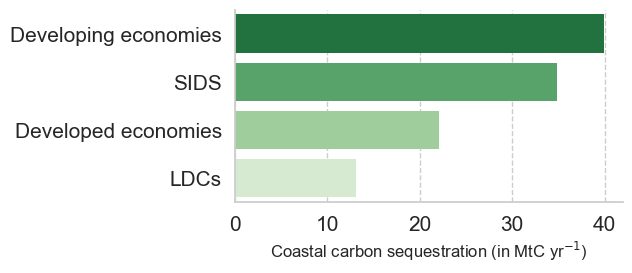

In [105]:
# paper2
grou = ddf.groupby('Groups')['uptake_total_mean'].sum().sort_values(ascending=False).reset_index()
grou['uptake_total_mean'] = grou['uptake_total_mean']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2.5))
sns.barplot(
    data=grou, x='uptake_total_mean', y='Groups', 
    width=0.8, palette='Greens_r', edgecolor='none'
)
plt.ylabel('')
plt.xlabel('Coastal carbon sequestration (in MtC yr$^{-1}$)')
sns.despine()
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

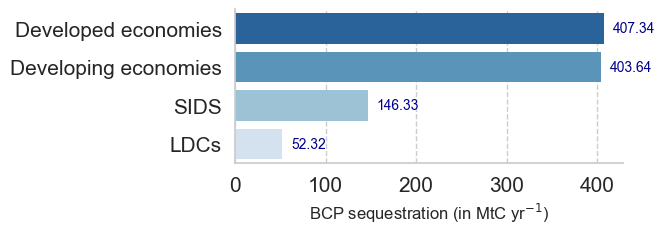

In [106]:
# paper3
grou = ddf.groupby('Groups')['BCP Seq (tC)'].sum().sort_values(ascending=False).reset_index()
grou['BCP Seq (tC)'] = grou['BCP Seq (tC)']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2))
sns.barplot(
    data=grou, x='BCP Seq (tC)', y='Groups', 
    width=0.8, palette='Blues_r', edgecolor='none'
    )
# text on bars
for p in plt.gca().patches:
    plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2,
                   f'{p.get_width():.2f}', va='center', ha='left', fontsize=10, color='darkblue')
plt.ylabel('')
plt.xlabel('BCP sequestration (in MtC yr$^{-1}$)')
sns.despine()
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

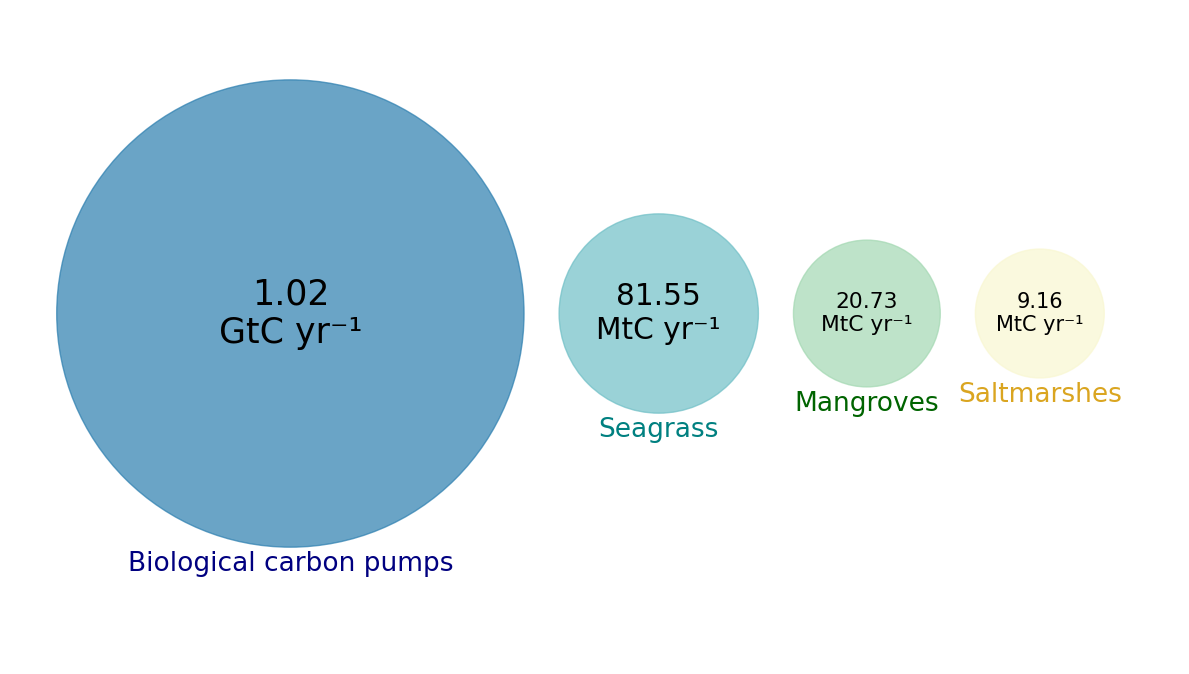

In [15]:
# paper3
ecosystem_totals.index = ["Biological carbon pumps", "Seagrass", "Mangroves", "Saltmarshes"]
circle_area_plot(
    ecosystem_totals=ecosystem_totals,
    colors=['#2b7eaf', '#6fbfc6', '#a3d8b2', '#f9f7d1'],
    label_colors=['navy', 'teal', 'darkgreen', 'goldenrod']
)

In [45]:
sns.set_theme(style='whitegrid')

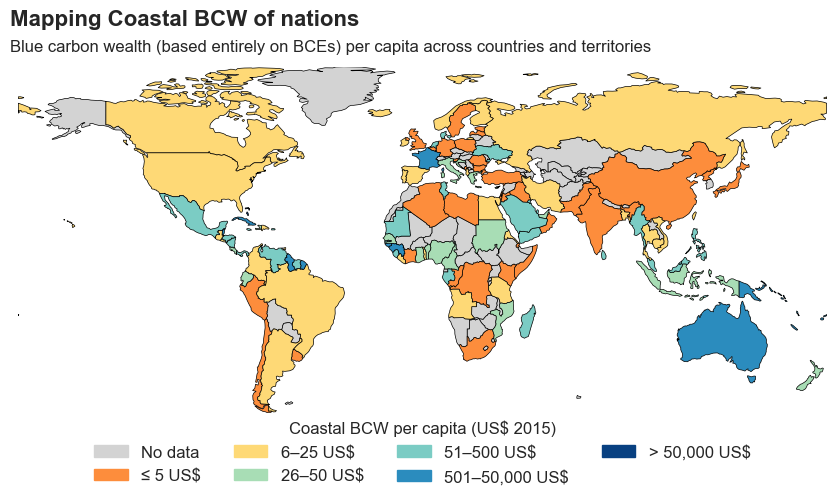

In [46]:
# paper4
mb_data = plot_data.copy()
mb_data['cBCW_per_capita'] = mb_data['cBCW'] / mb_data['Population']
mb_data.rename(columns={'cBCW_per_capita': 'Coastal BCW per capita (US$ 2015)'}, inplace=True)

hex_col2 = ['#27203f', '#51618f', '#7da6c0', '#a3c8d6', '#c2e2e2']
colors_hex = [
    "#e31a1c",  # Over 80%
    "#fd8d3c",  # 70-80%
    "#fed976",  # 60-70%
    "#f7fcb9",  # 50-60%
    "#ccebc5",  # 50%
    "#a8ddb5",  # 40-50%
    "#7bccc4",  # 30-40%
    "#4eb3d3",  # 20-30%
    "#2b8cbe",  # 10-20%
    "#0868ac",  # 0%-10%
    "#084081",  # 0%
]
colors_hex_6 = [
    "#ccebc5",  # vert très pâle (presque neutre, pour la transition)
    "#a8ddb5",  # vert-bleu clair
    "#7bccc4",  # bleu turquoise clair
    "#4eb3d3",  # bleu clair
    "#2b8cbe",  # bleu moyen
    "#084081",  # bleu foncé
]
hex_col2 = ['#27213f', '#3e406b', '#6685ab', '#7da7c0', '#9cc7d1', '#e6f2f2']
list_col2 = hex_col2[::-1]
colors_hex_6 = [
    "#fd8d3c",  # orange
    "#fed976",  # jaune
    "#a8ddb5",  # vert-bleu clair
    "#7bccc4",  # bleu turquoise clair
    # "#4eb3d3",  # bleu clair
    "#2b8cbe",  # bleu moyen
    "#084081",  # bleu foncé
]

map_and_barplot(
    df=mb_data,
    var='Coastal BCW per capita (US$ 2015)',
    bar=False,
    group_col='Groups',
    units='US$',
    thresholds=[-1, 5, 25, 50, 500, 50000],
    mapping=mapping,
    colors=colors_hex_6,
    title='Mapping Coastal BCW of nations',
    subtitle='Blue carbon wealth (based entirely on BCEs) per capita across countries and territories',
    xlabel_bar='Blue carbon wealth (in US$)',
    fig_size_map=(10, 6),
    legend_bbox=(0.5, -0.25),
    legend_ncol=4,
    fig_size_bar=(5, 2),
    cmap_palette='Blues',
    wld=world
)

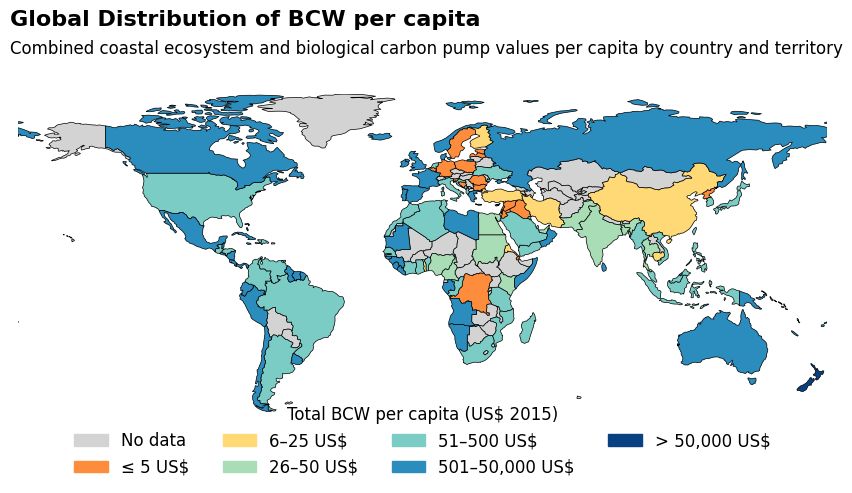

In [17]:
# paper4
mb_data.rename(columns={'Total BCW_per_capita': 'Total BCW per capita (US$ 2015)'}, inplace=True)
map_and_barplot(
    df=mb_data,
    var='Total BCW per capita (US$ 2015)',
    group_col='Groups',
    bar=False,
    units='US$',
    thresholds=[-1, 5, 25, 50, 500, 50000],
    mapping=mapping,
    colors=colors_hex_6,
    title='Global Distribution of BCW per capita',
    subtitle='Combined coastal ecosystem and biological carbon pump values per capita by country and territory',
    xlabel_bar='Blue carbon wealth (in US$)',
    fig_size_map=(10, 6),
    legend_bbox=(0.5, -0.25),
    legend_ncol=4,
    fig_size_bar=(5, 2),
    cmap_palette='Blues',
    wld=world
)

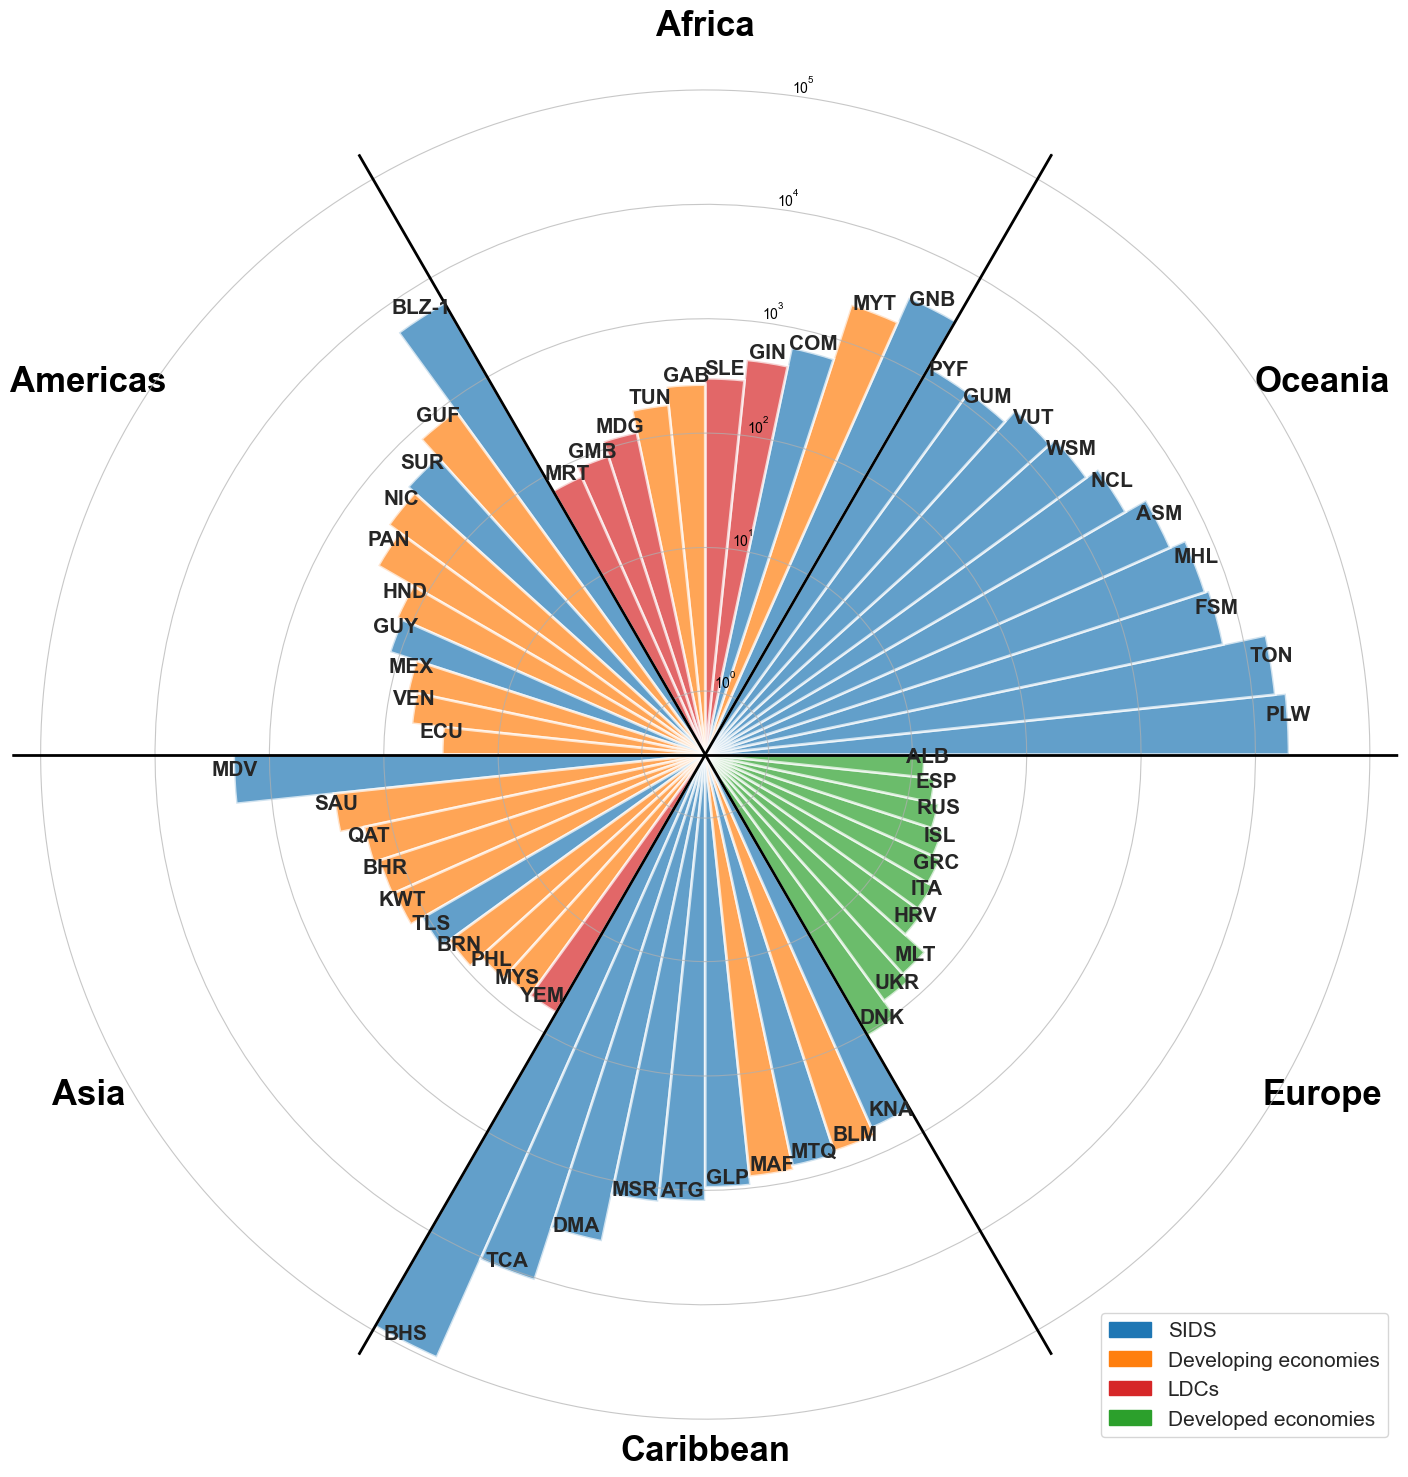

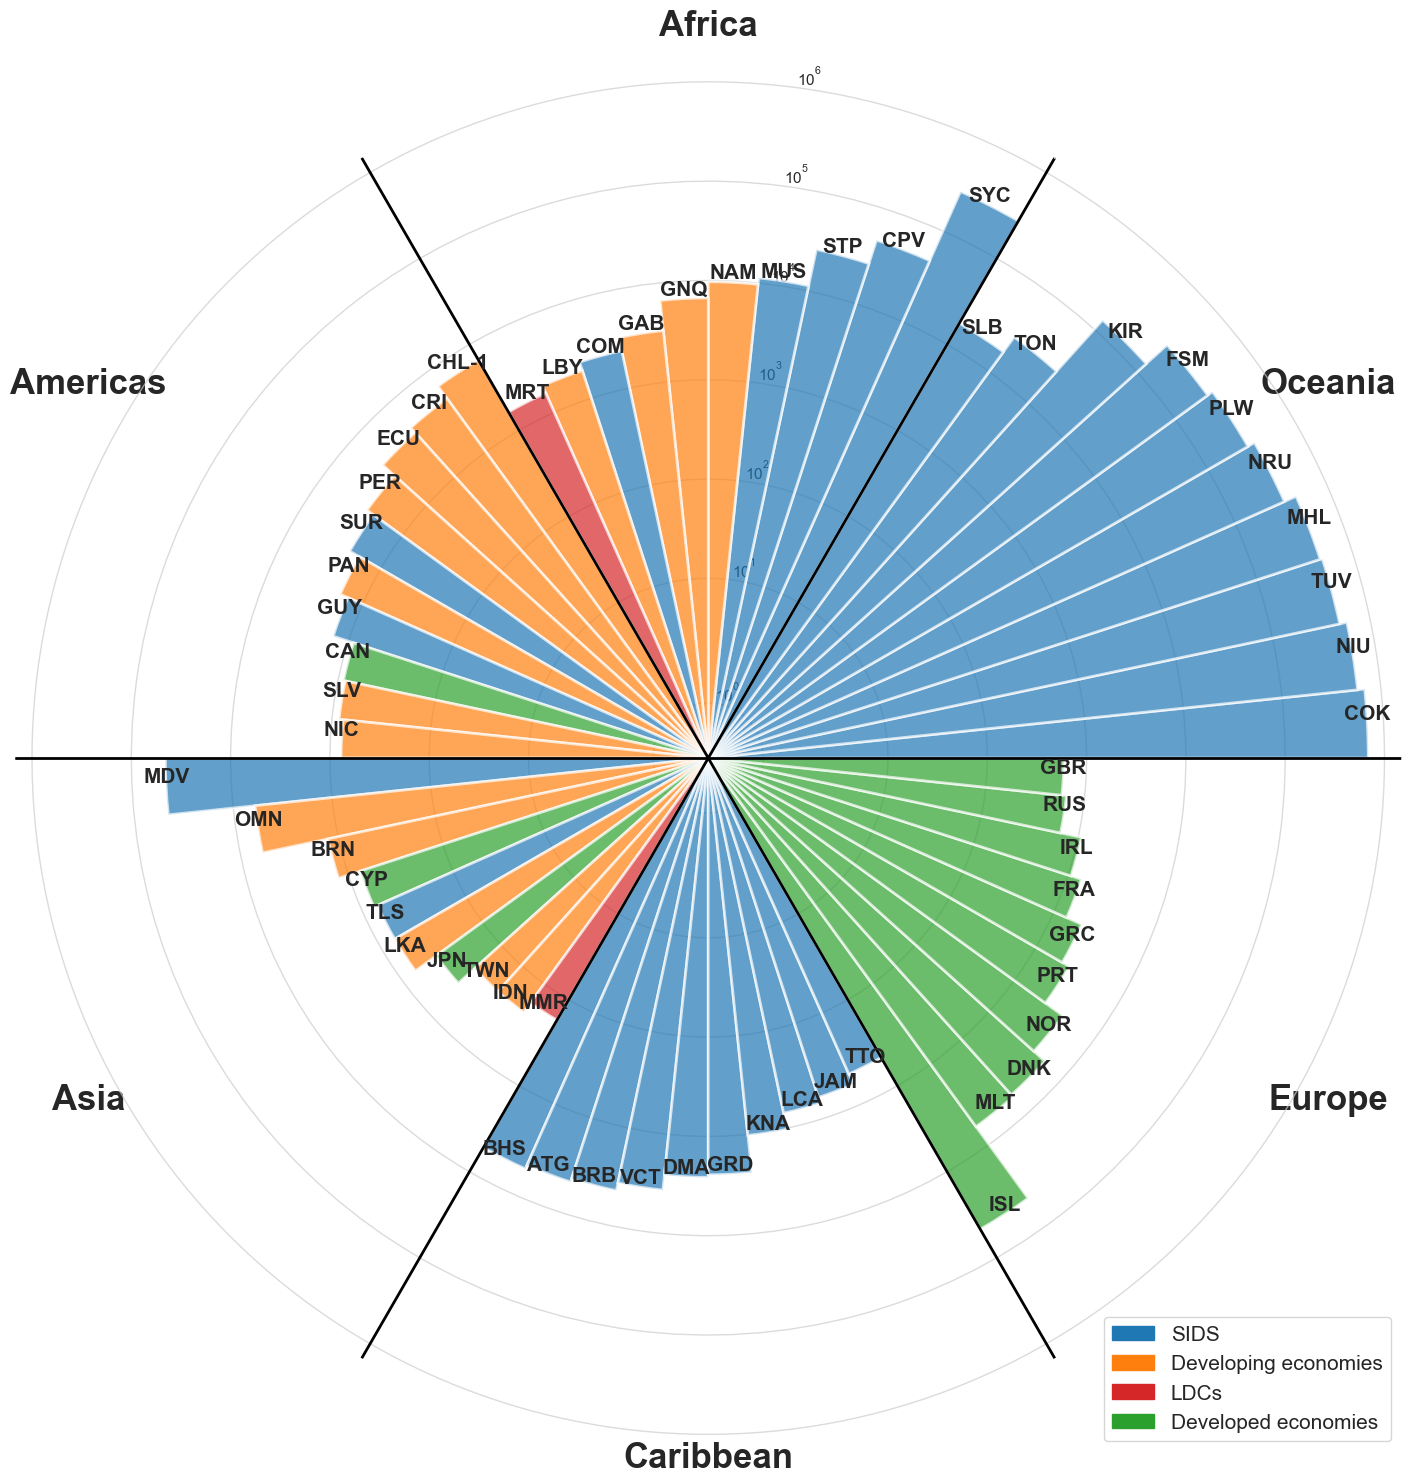

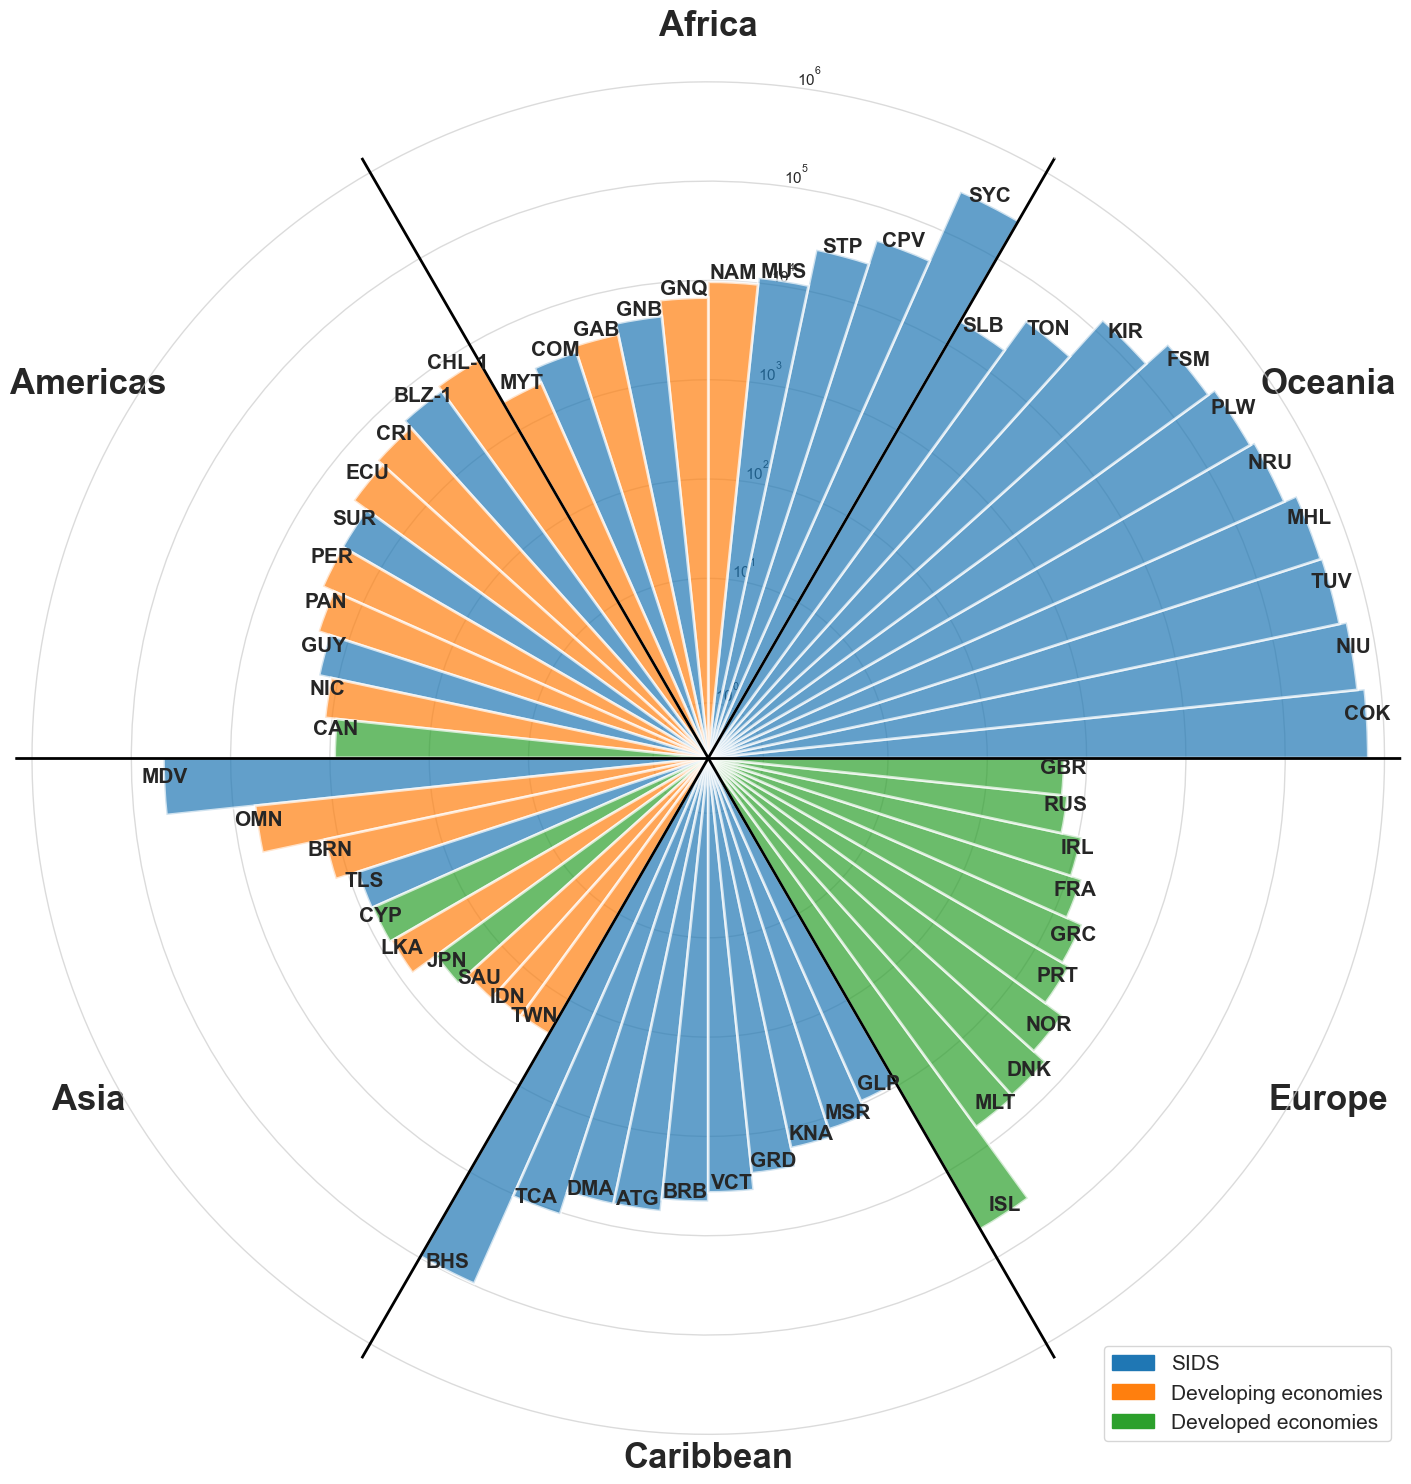

In [18]:
# paper4
df = data.copy()
pf = df[[
    'Continent', 'ISO', 'Groups', 'cBCW_per_capita', 
    'oBCW_per_capita', 'Total BCW_per_capita'
]].copy()

# Top 10 countries for each Continent by cBCW_per_capita, oBCW_per_capita and Total BCW_per_capita
top_10_bcw = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'cBCW_per_capita')).reset_index(drop=True)
top_10_bcw.drop(columns=['oBCW_per_capita', 'Total BCW_per_capita'], inplace=True)
top_10_oBCW = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'oBCW_per_capita')).reset_index(drop=True)
top_10_oBCW.drop(columns=['cBCW_per_capita', 'Total BCW_per_capita'], inplace=True)
top_10_Total_BCW = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'Total BCW_per_capita')).reset_index(drop=True)
top_10_Total_BCW.drop(columns=['cBCW_per_capita', 'oBCW_per_capita'], inplace=True)

datasets = [top_10_bcw, top_10_oBCW, top_10_Total_BCW]

category_colors = {
    'SIDS': '#1f77b4',
    'Developing economies': '#ff7f0e',
    'Developed economies': '#2ca02c',
    'LDCs': '#d62728'
}
for dta in datasets:
    if 'cBCW_per_capita' in dta.columns:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'cBCW_per_capita'
        category_col = 'Groups'
    elif 'oBCW_per_capita' in dta.columns:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'oBCW_per_capita'
        category_col = 'Groups'
    else:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'Total BCW_per_capita'
        category_col = 'Groups'

    wind_rose(dta, segment_col=segment_col, label_col=label_col, value_col=value_col,
              category_col=category_col, n_top=10, figsize=(18, 18), category_colors=category_colors)

In [19]:
# paper6
# Select relevant columns
tbl = data[['ISO', 'country_name', 'Groups', 'Continent', 'Area_EEZ_KM2',
            'Area_EEZ_KM2_per_capita', 'Total BCW', 'Total BCW_per_capita', 'GDP', 'GDP_per_capita',
            'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']].copy()

# Numerical columns to summarise
num_cols = ['Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'Total BCW', 'Total BCW_per_capita',
            'GDP', 'GDP_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']

# Conversion factors for units
conversion_factors = {
    'Area_EEZ_KM2':               1 / 1_000,
    'Total BCW':                  1 / 1_000_000_000,
    'Total BCW_per_capita':       1,
    'GDP':                        1 / 1_000_000_000,
    'GDP_per_capita':             1,
    'Debt (2015 US$)':            1 / 1_000_000_000,
    'Debt (2015 US$)_per_capita': 1,
}

# Stats for all countries
results = [stats_for_group(tbl, 'All-Countries', num_cols, conversion_factors)]

# Stats for each group
for g in sorted(tbl['Groups'].dropna().unique()):
    sub_df = tbl[tbl['Groups'] == g]
    results.append(stats_for_group(sub_df, g, num_cols, conversion_factors))

# Fusion and formatting
summary_final = pd.concat(results, ignore_index=True)
summary_final.columns = [
    "Groups", "No.", "Stat",
    "EEZ Area (1,000 km²)", "EEZ per capita",
    "Total BCW (billion US$)", "Total BCW per capita",
    "GDP (billion US$)", "GDP per capita",
    "TED (billion US$)", "TED per capita",
]

summary_final.to_csv(SUMMARY_DIR / 'data_summary.csv', index=False, float_format='%.2f')
summary_final

,Groups,No.,Stat,"EEZ Area (1,000 km²)",EEZ per capita,Total BCW (billion US$),Total BCW per capita,GDP (billion US$),GDP per capita,TED (billion US$),TED per capita
0,All-Countries,294,mean,972.2630,4.5110,12.1870,"23,238.5830",449.0780,"17,238.7570",56.0550,"1,933.0830"
1,All-Countries,294,median,342.1180,0.0450,2.0860,480.9250,27.9940,"6,539.9530",9.6800,"1,079.6420"
2,All-Countries,294,std,"2,411.7710",20.2010,25.0290,"94,682.6520","2,013.8570","25,400.8860",185.9780,"2,169.4110"
3,Developed economies,69,mean,"1,391.7570",1.5890,22.5940,"2,542.9660","1,015.6120","39,293.5240",30.1620,"4,561.9090"
4,Developed economies,69,median,266.7420,0.0220,1.2090,130.1120,215.3020,"34,097.2050",10.0510,"3,427.7690"
5,Developed economies,69,std,"4,036.4540",10.4170,40.2440,"7,936.1500","3,076.4600","35,046.2700",43.1420,"2,528.3110"
6,Developing economies,94,mean,"1,072.0940",4.0060,14.4460,"1,019.8880",525.8570,"8,489.0560",113.3190,"2,013.0240"
7,Developing economies,94,median,457.1910,0.0280,4.4990,209.2050,77.0060,"5,181.7450",30.3150,"1,180.5850"
8,Developing economies,94,std,"1,921.4390",19.5670,25.4120,"1,955.4780","2,110.6490","9,578.2650",271.1830,"1,911.7740"
9,LDCs,37,mean,701.4420,0.0360,6.3930,375.2030,33.8880,"1,039.3710",12.1800,515.9170


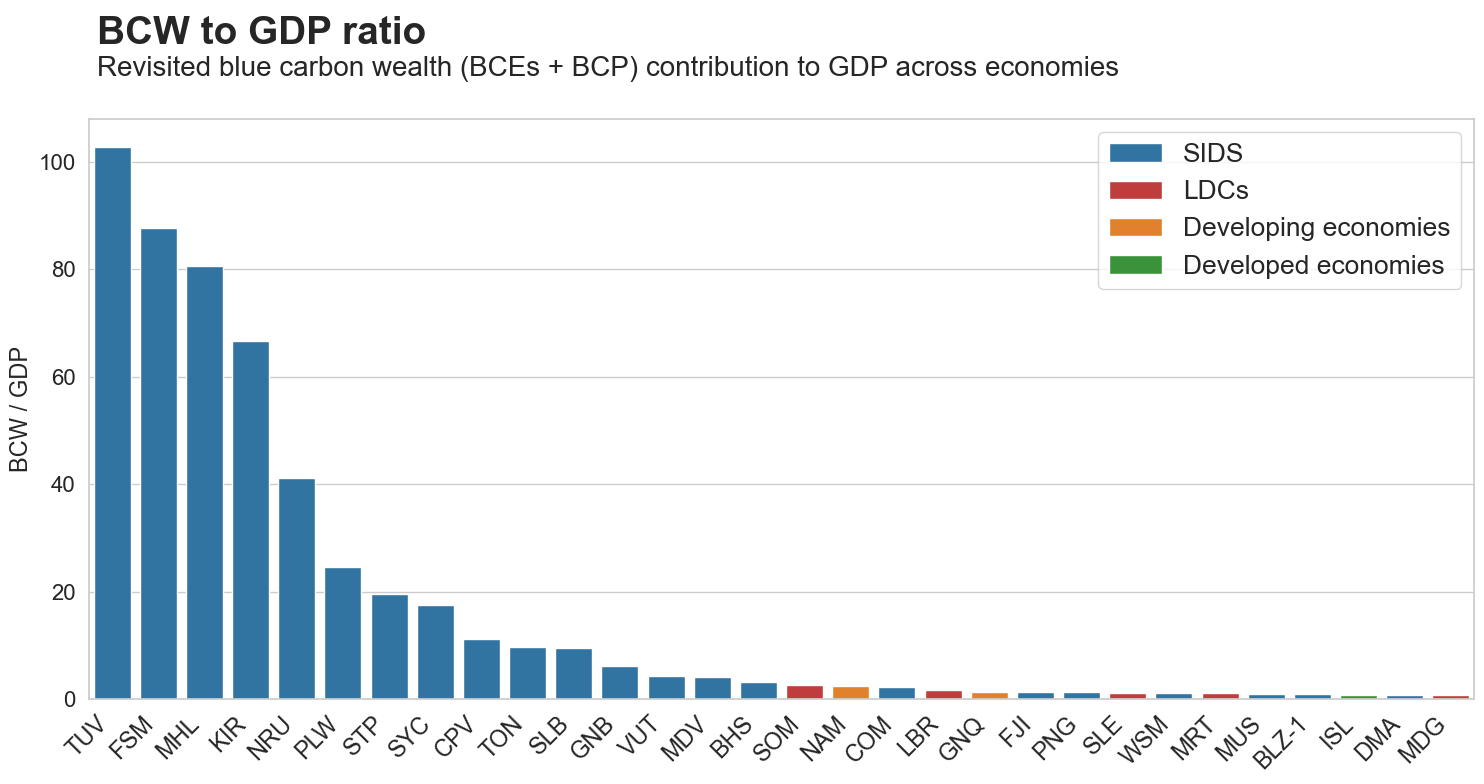

In [20]:
# paper7
by_bg = df[['ISO', 'Groups', 'Total BCW', 'GDP']]
by_bg['Total BCW to GDP ratio'] = by_bg['Total BCW'] / by_bg['GDP']
by_bg['Total BCW to GDP ratio'] = by_bg['Total BCW to GDP ratio'].replace([np.inf, -np.inf], np.nan)
by_bg = by_bg.sort_values(by='Total BCW to GDP ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(15, 8))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='Total BCW to GDP ratio', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'BCW to GDP ratio', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Revisited blue carbon wealth (BCEs + BCP) contribution to GDP across economies', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('BCW / GDP', fontsize=17)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xticks(rotation=45, ha='right', fontsize=17)
plt.tight_layout()
plt.legend(fontsize=19)
plt.show()

In [21]:
selection = [
    "ISO", "country_name", "Continent", "Groups",
    "Population", "GDP", "Debt (2015 US$)", "CO2_emissions_2023",
    "uptake_total_mean", "BCP Seq (tC)",
    "cBCW", "Total BCW"
]
df = data[selection].copy()

# Without BCP (only BCE)
df["S_BCE"] = df["uptake_total_mean"] * CMOL

# With BCP
df["S_BCE_BCP"] = df["BCP Seq (tC)"] * CMOL
df["S_ALL"] = df["S_BCE"] + df["S_BCE_BCP"]

df["E"] = df["CO2_emissions_2023"] # CO2 emissions in 2023 (tCO2)

# A) Net balance (soft "carbon budget")
df["NetCO2_BCE"] = df["S_BCE"] - df["E"]
df["NetCO2_ALL"] = df["S_ALL"] - df["E"]
df["Delta_NetCO2"] = df["NetCO2_ALL"] - df["NetCO2_BCE"]

df["is_net_sink_BCE"] = df["NetCO2_BCE"] < 0
df["is_net_sink_ALL"] = df["NetCO2_ALL"] < 0
df["switch_sink_status"] = df["is_net_sink_ALL"] != df["is_net_sink_BCE"]

# B) Coverage : years of emissions covered by the BCW
df["BCW_TOTAL"] = df["Total BCW"]
df["Coverage_BCE"] = df["cBCW"] / (df["E"] * gscc_value)
df["Coverage_ALL"] = df["BCW_TOTAL"] / (df["E"] * gscc_value)
df["Delta_Coverage"] = df["Coverage_ALL"] - df["Coverage_BCE"]

# C) Relief : % of debt that could be covered by the BCW
df["Relief_BCE"] = (df["S_BCE"] * gscc_value) / df["Debt (2015 US$)"]
df["Relief_ALL"] = (df["S_ALL"] * gscc_value) / df["Debt (2015 US$)"]
df["Delta_Relief"] = df["Relief_ALL"] - df["Relief_BCE"]

# Quadrants BCE and BCP
def quadrant(is_sink, high_stress):
    if (not is_sink) and high_stress: 
        return "Source + high debt stress"
    if (not is_sink) and (not high_stress): 
        return "Source + low debt stress"
    if is_sink and high_stress: 
        return "Sink + high debt stress"
    return "Sink + low debt stress"


out_cols = [
    "ISO","country_name","Continent","Groups",
    "E","S_BCE","S_ALL",
    "NetCO2_BCE","NetCO2_ALL","Delta_NetCO2",
    "cBCW","Total BCW","Coverage_BCE","Coverage_ALL","Delta_Coverage",
    "Debt (2015 US$)","Debt_to_GDP","Relief_BCE","Relief_ALL","Delta_Relief",
    "Quadrant_BCE","Quadrant_ALL","switch_sink_status","switch_quadrant"
]

# ----------------------------
# outputs "paper-ready"
# ----------------------------
# (C) Typology of countries by net sink/source status and debt stress (using debt/GDP ratio)
df["Debt_to_GDP"] = df["Debt (2015 US$)"] / df["GDP"]
thr = df["Debt_to_GDP"].median(skipna=True)
df["high_debt_stress"] = df["Debt_to_GDP"] >= thr

df["Quadrant_BCE"] = [quadrant(s, h) for s, h in zip(df["is_net_sink_BCE"], df["high_debt_stress"])]
df["Quadrant_ALL"] = [quadrant(s, h) for s, h in zip(df["is_net_sink_ALL"], df["high_debt_stress"])]
df["switch_quadrant"] = df["Quadrant_BCE"] != df["Quadrant_ALL"]

quadrant_switch = df[df["switch_quadrant"]].sort_values("Delta_NetCO2").copy()
# (A) Top movers: BCP effect
top_delta_cov = df.sort_values("Delta_Coverage", ascending=False).head(25)
top_delta_relief = df.sort_values("Delta_Relief", ascending=False).head(25)

# (B) Who switches from net sink to net source or vice versa when including BCP Seq?
switchers = df[df["switch_sink_status"]].sort_values("Delta_NetCO2").copy()


df[out_cols].to_csv(OUTPUT_DIR / "bcw_finance_indicators.csv", index=False)
top_delta_cov[out_cols].to_csv(OUTPUT_DIR / "top_movers_delta_coverage.csv", index=False)
top_delta_relief[out_cols].to_csv(OUTPUT_DIR / "top_movers_delta_relief.csv", index=False)
switchers[out_cols].to_csv(OUTPUT_DIR / "switchers_sink_status.csv", index=False)
quadrant_switch[out_cols].to_csv(OUTPUT_DIR / "switchers_quadrant.csv", index=False)

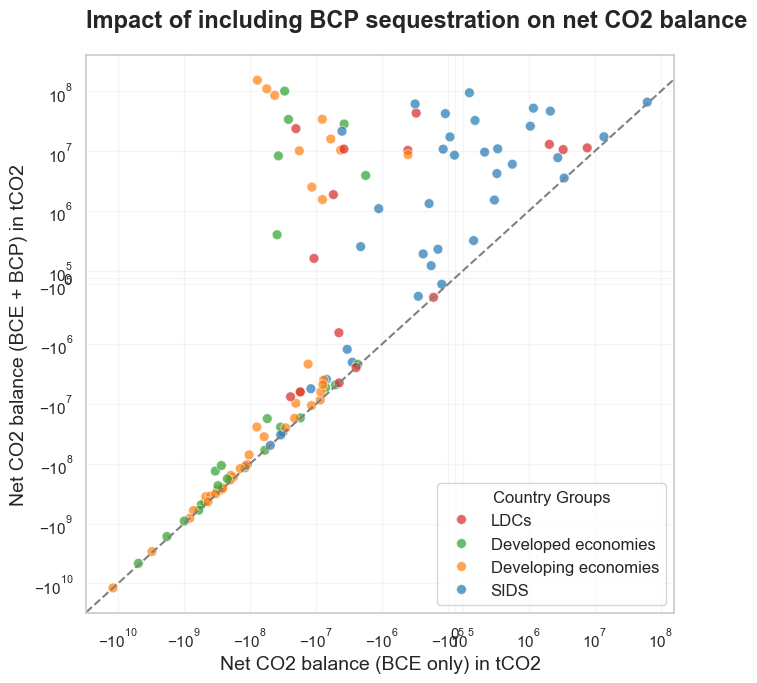

In [22]:
# paper7
# Plot : scatter NetCO2_BCE (x) vs NetCO2_BCP (y) avec ligne y=x.
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=df, x='NetCO2_BCE', y='NetCO2_ALL', hue='Groups', 
    palette=color_mapping, s=50, alpha=0.7
)
plt.axline((0, 0), slope=1, color='gray', linestyle='--')
plt.xlabel('Net CO2 balance (BCE only) in tCO2', fontsize=14)
plt.ylabel('Net CO2 balance (BCE + BCP) in tCO2', fontsize=14)
plt.title(
    'Impact of including BCP sequestration on net CO2 balance', 
    fontsize=17, fontweight='bold', pad=20, loc='left'
)
plt.yscale('symlog', linthresh=1e6)
plt.xscale('symlog', linthresh=1e6)
plt.legend(title='Country Groups', fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()

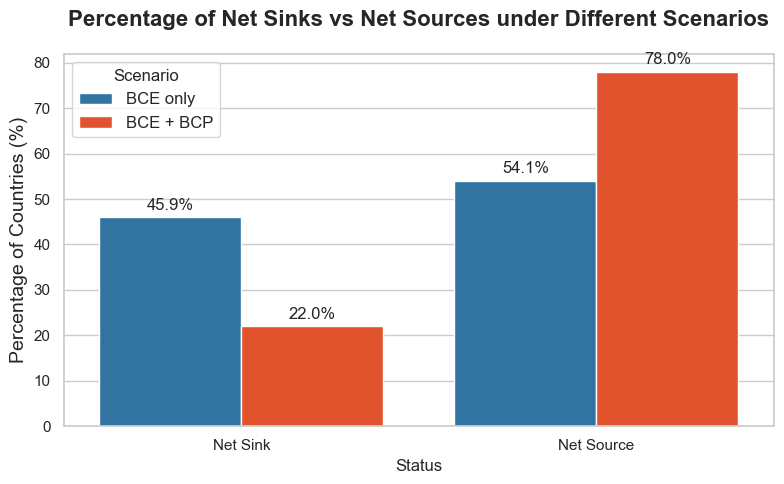

In [23]:
# paper7
# Plot : bar chart : % "net sink" en BCE vs % "net sink" en BCE+BCP + % switchers.
summary = pd.DataFrame({
    'Status': ['Net Sink', 'Net Source'],
    'BCE only': [
        df['is_net_sink_BCE'].mean() * 100, 
        (1 - df['is_net_sink_BCE'].mean()) * 100
    ],
    'BCE + BCP': [
        df['is_net_sink_ALL'].mean() * 100, 
        (1 - df['is_net_sink_ALL'].mean()) * 100
    ]
})

summary_melted = summary.melt(id_vars='Status', var_name='Scenario', value_name='Percentage')
plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary_melted, x='Status', y='Percentage', 
    hue='Scenario', palette=['#1f77b4', "#ff420e"]
)
plt.ylabel('Percentage of Countries (%)', fontsize=14)
plt.title(
    'Percentage of Net Sinks vs Net Sources under Different Scenarios', 
    fontsize=16, fontweight='bold', pad=20
)
for index, row in summary_melted.iterrows():
    plt.text(
        index % 2 + (index // 2) * 0.4 - 0.2, 
        row['Percentage'] + 1, 
        f"{row['Percentage']:.1f}%", 
        ha='center', va='bottom', fontsize=12
    )
plt.legend(title='Scenario', fontsize=12)
plt.tight_layout()
plt.show()

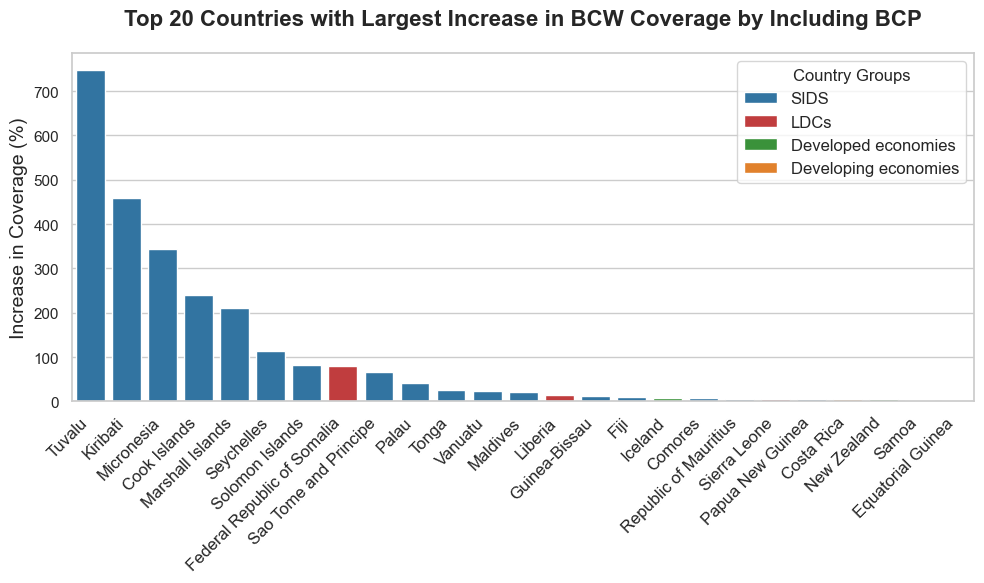

In [24]:
# paper7
# Plot : bar chart des 20 plus grands Delta_Coverage
# top_delta_cov
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_delta_cov, x='country_name', y='Delta_Coverage', 
    palette=color_mapping, hue='Groups'
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Increase in Coverage (%)', fontsize=14)
plt.xlabel('')
plt.title(
    'Top 20 Countries with Largest Increase in BCW Coverage by Including BCP', 
    fontsize=16, fontweight='bold', pad=20
)
plt.legend(title='Country Groups', fontsize=12)
plt.tight_layout()
plt.show()

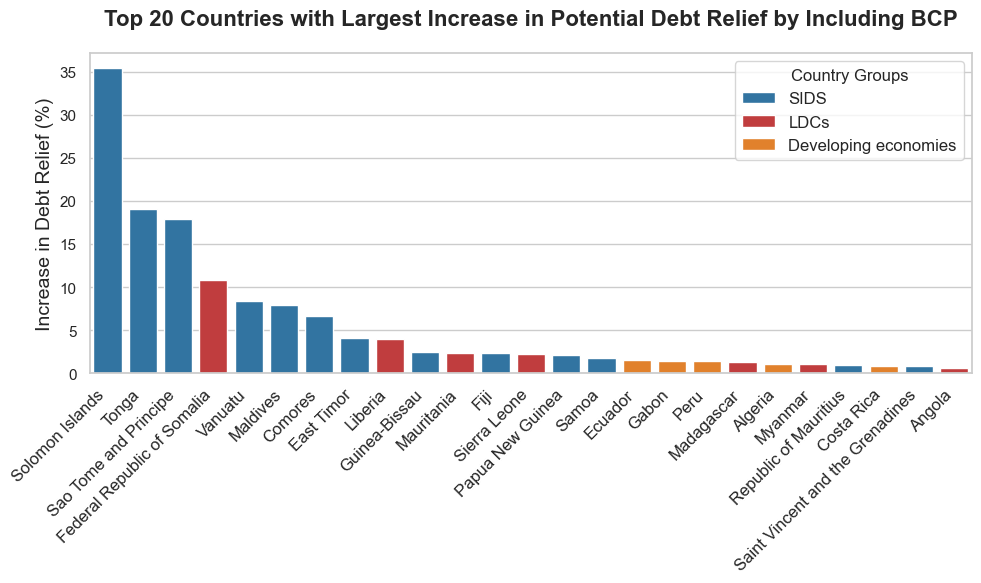

In [25]:
# paper7
# Plot : bar chart top 20 Delta_Relief
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_delta_relief, x='country_name', y='Delta_Relief', 
    palette=color_mapping, hue='Groups'
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Increase in Debt Relief (%)', fontsize=14)
plt.xlabel('')
plt.title(
    'Top 20 Countries with Largest Increase in Potential Debt Relief by Including BCP', 
    fontsize=16, fontweight='bold', pad=20
)
plt.legend(title='Country Groups', fontsize=12)
plt.tight_layout()
plt.show()

In [102]:
# top and flop Quadrant_BCE by GDP and Coverage_BCE
top_quadrant_bce = (df
    .sort_values(['Quadrant_BCE', 'GDP', 'Coverage_BCE'], ascending=[True, False, False])
    .groupby('Quadrant_BCE')
    .head(3)
)
flop_quadrant_bce = (df
    .sort_values(['Quadrant_BCE', 'GDP', 'Coverage_BCE'], ascending=[False, True, True])
    .groupby('Quadrant_BCE')
    .head(3)
)

big_list = pd.concat([top_quadrant_bce, flop_quadrant_bce], ignore_index=True)
big_list = big_list['country_name'].unique().tolist() + ["China", "United States", "India", "Indonesia", "Brazil", "Russia"]
# drop duplicates in big_list
big_list = list(dict.fromkeys(big_list))

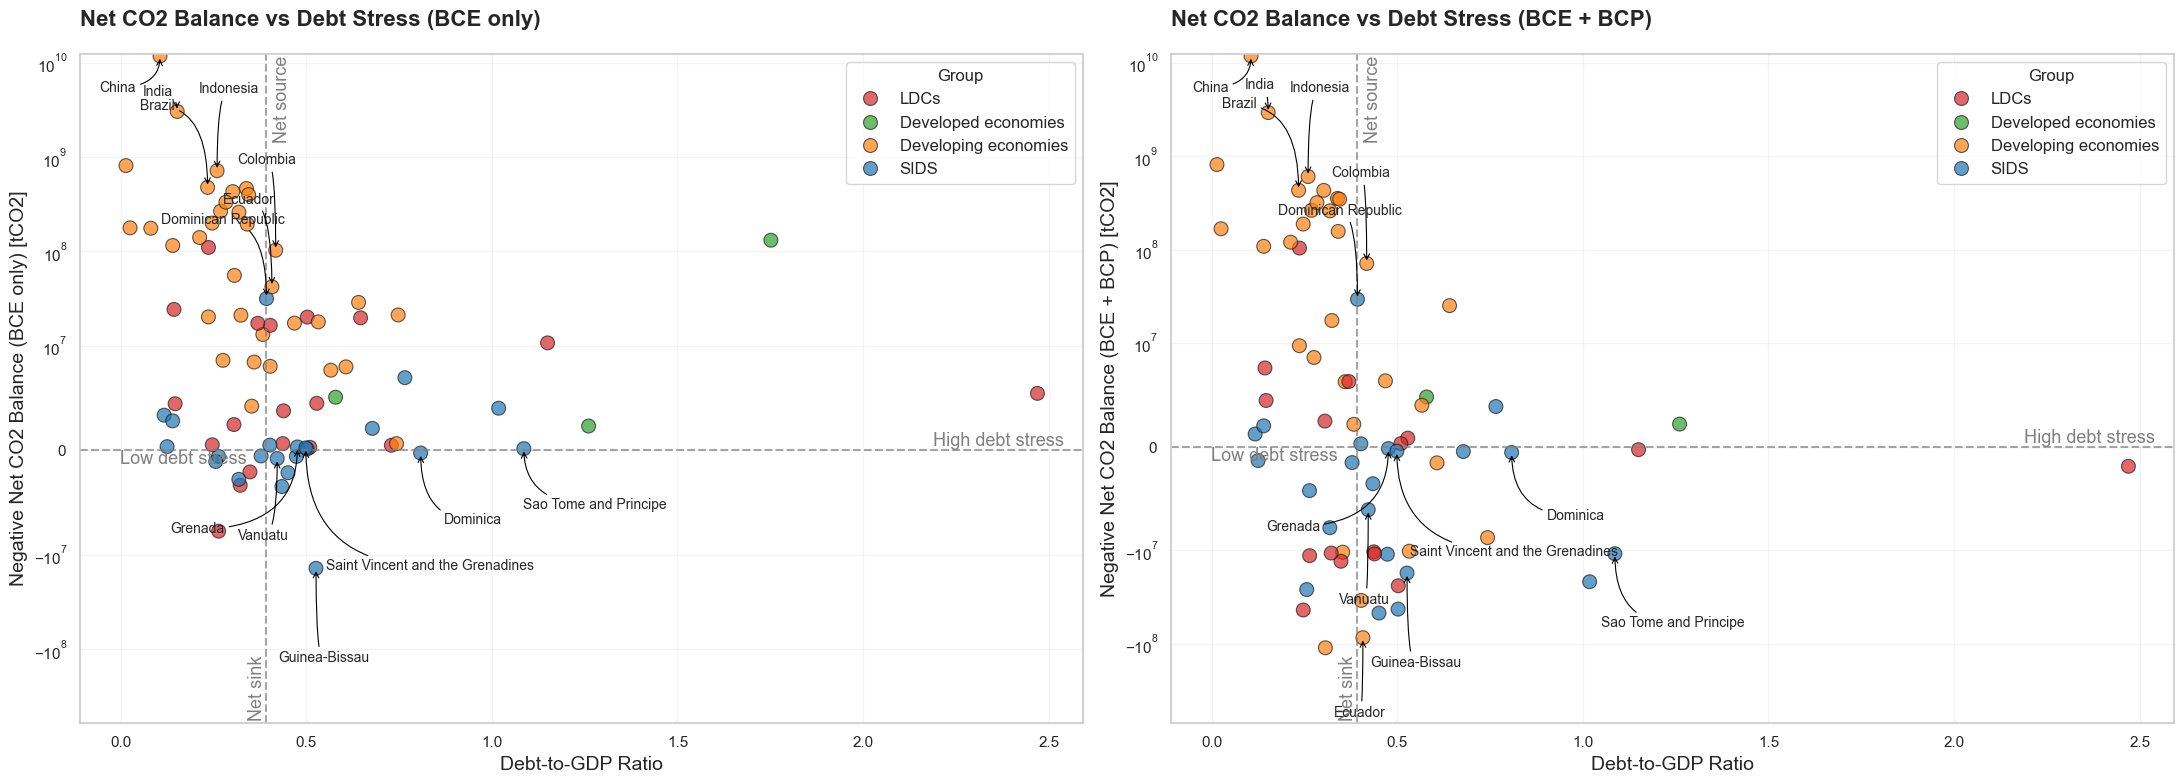

In [103]:
countries_to_label = list(set(big_list))
fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharex=True)

for i, (ax, ycol, title, ylab) in enumerate([
    (axes[0], "-df['NetCO2_BCE']", "Net CO2 Balance vs Debt Stress (BCE only)", "Negative Net CO2 Balance (BCE only) [tCO2]"),
    (axes[1], "-df['NetCO2_ALL']", "Net CO2 Balance vs Debt Stress (BCE + BCP)", "Negative Net CO2 Balance (BCE + BCP) [tCO2]")
]):
    ydata = -df["NetCO2_BCE"] if i == 0 else -df["NetCO2_ALL"]
    sns.scatterplot(
        data=df, x="Debt_to_GDP", y=ydata,
        hue="Groups", palette=color_mapping, s=100, alpha=0.7, edgecolor="k", ax=ax
    )
    thr = df["Debt_to_GDP"].median(skipna=True)
    ax.axvline(thr, color='gray', linestyle='--', alpha=0.7)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # X axis: Debt stress labels
    ax.text(
        xlim[1] * 0.98, 0, "High debt stress",
        va="bottom", ha="right", fontsize=13, color="gray", rotation=0,
        bbox=dict(facecolor='none', edgecolor='none', alpha=0)
    )
    ax.text(
        xlim[0] * 0.01, 0, "Low debt stress",
        va="top", ha="left", fontsize=13, color="gray", rotation=0,
        bbox=dict(facecolor='none', edgecolor='none', alpha=0)
    )

    # Y axis: Net source/sink labels
    ax.text(
        thr + (xlim[1] - thr) * 0.03, ylim[1] * 0.95, "Net source",
        va="top", ha="right", fontsize=13, color="gray", rotation=90,
        bbox=dict(facecolor='none', edgecolor='none', alpha=0)
    )
    ax.text(
        thr , ylim[0] * 0.95, "Net sink",
        va="bottom", ha="right", fontsize=13, color="gray", rotation=90,
        bbox=dict(facecolor='none', edgecolor='none', alpha=0), 
        # transform=ax.get_yaxis_transform()
    )

    ax.set_xlabel("Debt-to-GDP Ratio", fontsize=14)
    ax.set_ylabel(ylab, fontsize=14)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20, loc="left")
    ax.set_yscale("symlog", linthresh=1e7)
    ax.grid(alpha=0.2)

    # Annotate selected countries
    col = "NetCO2_BCE" if i == 0 else "NetCO2_ALL"
    subset = df[df["country_name"].isin(countries_to_label)].dropna(subset=["Debt_to_GDP", col])
    texts_data = [
        (r["Debt_to_GDP"], -r[col], r["country_name"])
        for _, r in subset.iterrows()
    ]
    smart_annotate(ax, texts_data, offset_radius=65)
    ax.legend(title="Group", fontsize=12)

plt.tight_layout()
plt.show()

## Supplementary Figures

Additional bar charts and combined plots for publication appendix.

In [27]:
# supl1
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq", "Continent"
]].copy()

mg_up = (
    uptakes
    .groupby("Continent")
    .sum()
    .sort_values(by='Total BCseq', ascending=False)
    .reset_index()
)

# convert tC to MtC and GtC where appropriate, and rename columns for clarity
mg_up.iloc[:, 1:] = mg_up.iloc[:, 1:] / 1e6
mg_up.columns = [
    "Continent", "Saltmarshes (MtC)", "Seagrasses (MtC)", "Mangroves (MtC)",
    "Total BCEs (MtC)", "BCP (MtC)", "Total Seq (MtC)"
]

mg_up = mg_up.round(2)

save_path = SUMMARY_DIR / 'continental_uptakes.csv'
mg_up.to_csv(save_path, index=False)
mg_up

,Continent,Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC),Total BCEs (MtC),BCP (MtC),Total Seq (MtC)
0,Americas,4.0600,5.9800,6.8400,16.8800,328.6100,345.4900
1,Europe,1.8500,3.3500,0.0000,5.2000,194.5400,199.7400
2,Oceania,2.2400,14.5900,3.0300,19.8600,176.8600,196.7200
3,Asia,0.9700,20.0000,5.2600,26.2300,153.5400,179.7700
4,Africa,0.0200,15.8300,5.1600,21.0200,157.5200,178.5400
5,Caribbean,0.0100,21.8000,0.4400,22.2500,6.0800,28.3300


In [28]:
# supl1
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq", "Groups"
]].copy()

mg_up = (
    uptakes
    .groupby('Groups')
    .sum()
    .sort_values(by='Total BCseq', ascending=False)
    .reset_index()
)

mg_up.iloc[:, 1:] = mg_up.iloc[:, 1:] / 1e6
mg_up.columns = [
    "Groups", "Saltmarshes (MtC)", "Seagrasses (MtC)", "Mangroves (MtC)",
    "Total BCEs (MtC)", "BCP (MtC)", "Total Seq MtC)"
]

mg_up = mg_up.round(2)
# mg_up['BCEs(%)'] = (mg_up['Total BCEs (MtC)'] / mg_up['Total BCEs (MtC)'].sum()).round(2) * 100
mg_up.to_csv(SUMMARY_DIR / 'grouping_uptakes.csv', index=False)
mg_up


,Groups,Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC),Total BCEs (MtC),BCP (MtC),Total Seq MtC)
0,Developing economies,1.7000,26.4800,11.7700,39.9500,403.6400,443.5900
1,Developed economies,7.1700,12.6100,2.3400,22.1100,407.3400,429.4600
2,SIDS,0.0100,32.5300,2.3500,34.8900,146.3300,181.2200
3,LDCs,0.0100,8.9600,4.1600,13.1300,52.3200,65.4500


In [ ]:
# supl2
continent = data.groupby('Continent')[['cBCW', 'oBCW', 'Total BCW', 'Population']].sum().reset_index()
continent['cBCW_per_capita'] = continent['cBCW'] / continent['Population']
continent['oBCW_per_capita'] = continent['oBCW'] / continent['Population']
continent['Total BCW_per_capita'] = continent['Total BCW'] / continent['Population']
continent.rename(columns={
    'oBCW': 'PCW', 'oBCW_per_capita': 'PCW_PCAP'
    }).to_csv(SUMMARY_DIR / 'continent_summary.csv', index=False, float_format='%.6f')
continent.head()

,Continent,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Africa,"43,107,834,064.2969","323,200,300,000.0000","366,308,127,572.0469","1,479,900,930.0000",29.1289,218.3932,247.5221
1,Americas,"34,580,563,750.5703","674,221,839,644.0000","708,802,367,980.0703","1,017,200,349.0000",33.9958,662.8211,696.8169
2,Asia,"53,818,429,353.6875","315,027,553,629.9362","368,845,993,287.3750","4,769,847,844.0000",11.2830,66.0456,77.3287
3,Caribbean,"45,701,131,562.9219","12,472,102,310.0000","58,173,234,921.6406","44,309,064.0000","1,031.4172",281.4797,"1,312.8969"
4,Europe,"10,668,659,308.3359","399,161,047,767.5210","409,829,716,252.8398","743,902,347.0000",14.3415,536.5772,550.9187


Regression equation: $y = 11.11 + 0.46x$ | $R² = 0.18$


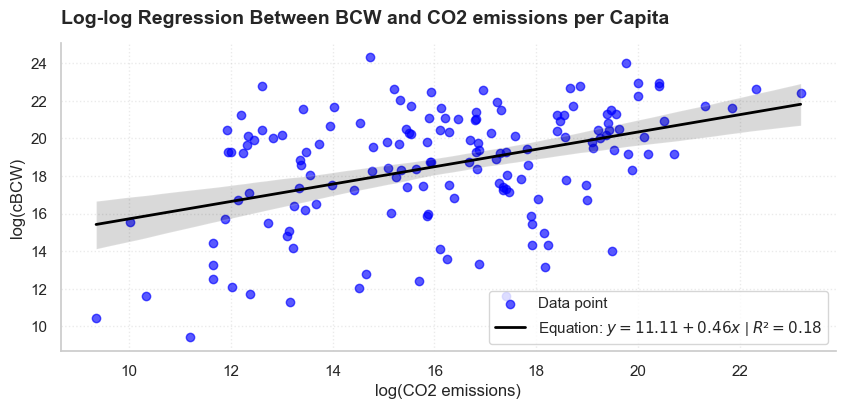

Regression equation: $y = -3.42 + 0.70x$ | $R² = 0.20$


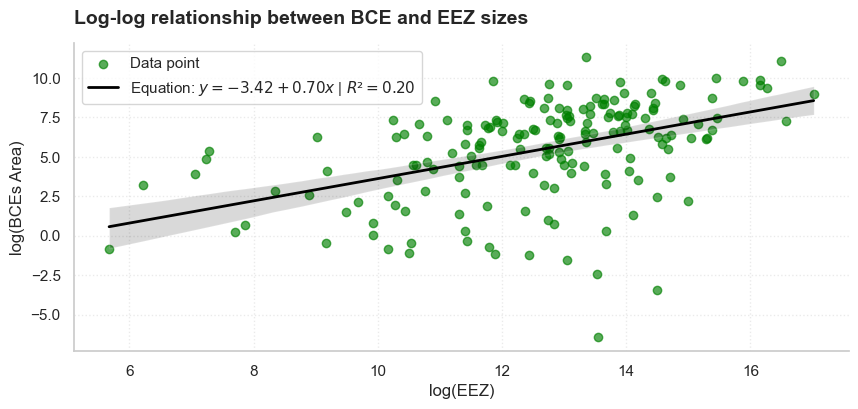

Regression equation: $y = -8.25 + -0.10x$ | $R² = 0.00$


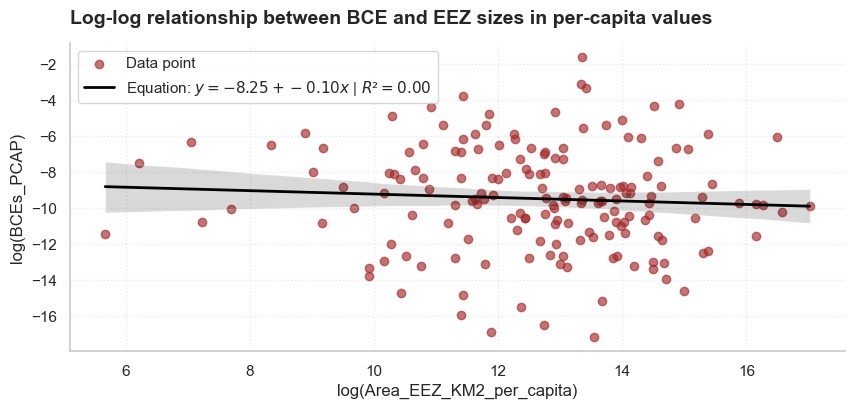

Regression equation: $y = 13.29 + 0.36x$ | $R² = 0.09$


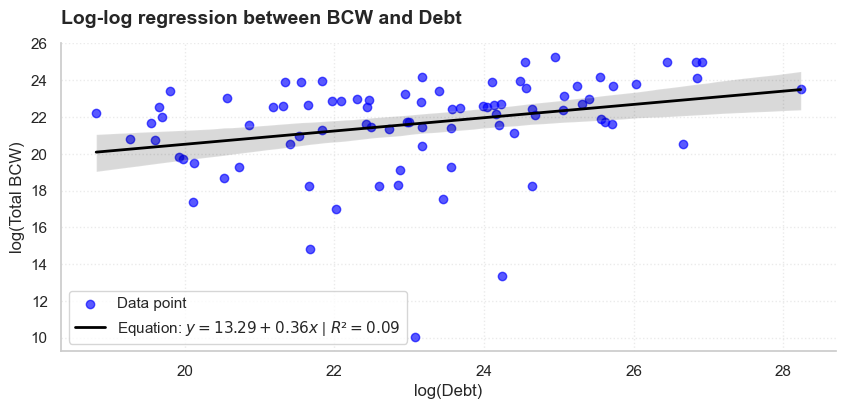

Regression equation: $y = 5.71 + 1.17x$ | $R² = 0.40$


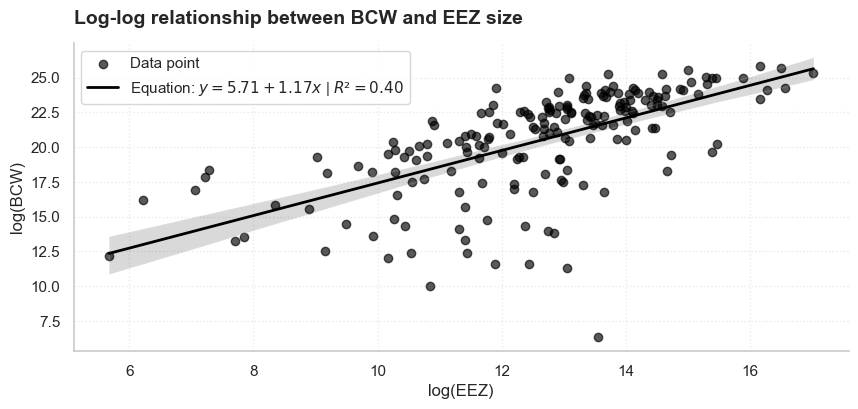

In [30]:
# supl3
regplotter(
    data, 'CO2_emissions_2023', 
    'log CO2',
    'Log-log Regression Between BCW and CO2 emissions per Capita',
    'CO2 emissions'
)

# ddf['BCEs area'] = ddf[[
#     'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
# ]].fillna(0).sum(axis=1).replace(0, np.nan)

ddt = data.copy()
ddt['BCEs Area'] = ddt[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].fillna(0).sum(axis=1).replace(0, np.nan)

ddt['Area_EEZ_KM2_per_capita'] = ddt['Area_EEZ_KM2'] / ddt['Population']
ddt['BCEs_PCAP'] = ddt['BCEs Area'] / ddt['Population']
ddt['cBCW'] = ddt['cBCW']
ddt['BCW'] = ddt['Total BCW']
ddt['EEZ'] = ddt['Area_EEZ_KM2']

regplotter(
    ddt, 'Area_EEZ_KM2', 'log(EEZ Size)',
    'Log-log relationship between BCE and EEZ sizes',
    'EEZ', 'BCEs Area', 'green'
)
regplotter(
    ddt, 'Area_EEZ_KM2', 'log(EEZ)',
    'Log-log relationship between BCE and EEZ sizes in per-capita values',
    'Area_EEZ_KM2_per_capita', 'BCEs_PCAP', 'brown'
)
regplotter(
    data, 'Debt (2015 US$)', 'log Debt',
    'Log-log regression between BCW and Debt',
    'Debt', 'Total BCW'
)

regplotter(
    ddt, 'EEZ', 'log(EEZ)',
    'Log-log relationship between BCW and EEZ size',
    'EEZ', 'BCW', 'black'
)


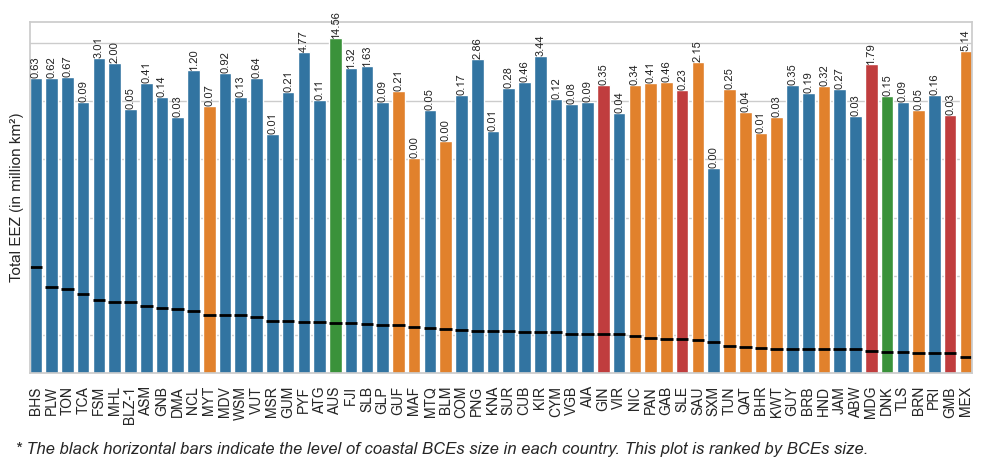

In [31]:
# supl4
by_eez = data.copy()
by_eez['EEZ'] = by_eez['Area_EEZ_KM2']
by_eez['BCEs_size'] = by_eez[['mangroves_area_km2', 'saltmarshes_area_km2', 'seagrasses_area_km2']].sum(axis=1)
by_eez['BCEs_size'] = by_eez['BCEs_size'] / by_eez['Population']
by_eez = by_eez[['ISO', 'Groups', 'EEZ', 'BCEs_size'
             ]].dropna(subset=['Groups']).sort_values(by='BCEs_size', ascending=False)
top = by_eez.head(60)

fig, ax = plt.subplots(figsize=(10, 4.5))

sns.barplot(
    data=top,
    y='EEZ', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

for i, row in by_eez.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['BCEs_size']) else row['BCEs_size']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,  
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.1, f'{height/1e6:,.2f}',
                ha='center', va='bottom', rotation=90, fontsize=8)
plt.ylabel('Total EEZ (in million km²)', fontsize=11)
plt.xlabel('')
# remove y tick labels
ax.set_yticklabels([], visible=False)
plt.xticks(rotation=90, ha='center')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend().remove()
plt.figtext(
    0.45, 0, 
    "* The black horizontal bars indicate the level of coastal BCEs size in each country. This plot is ranked by BCEs size.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

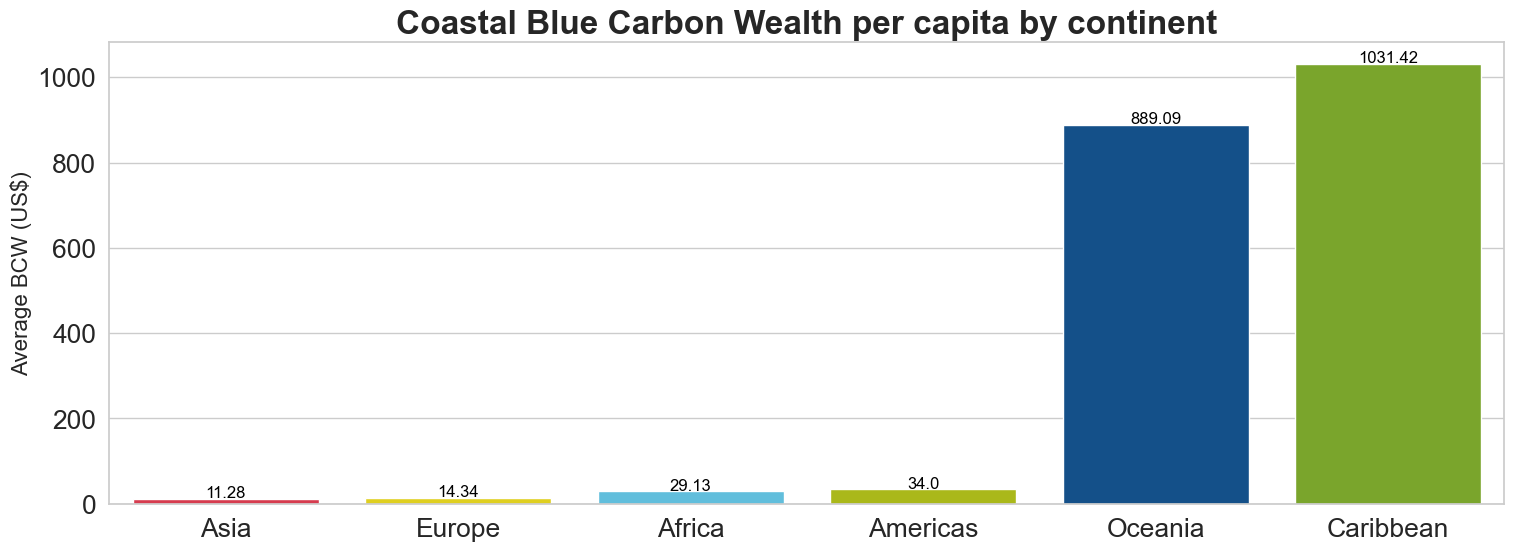

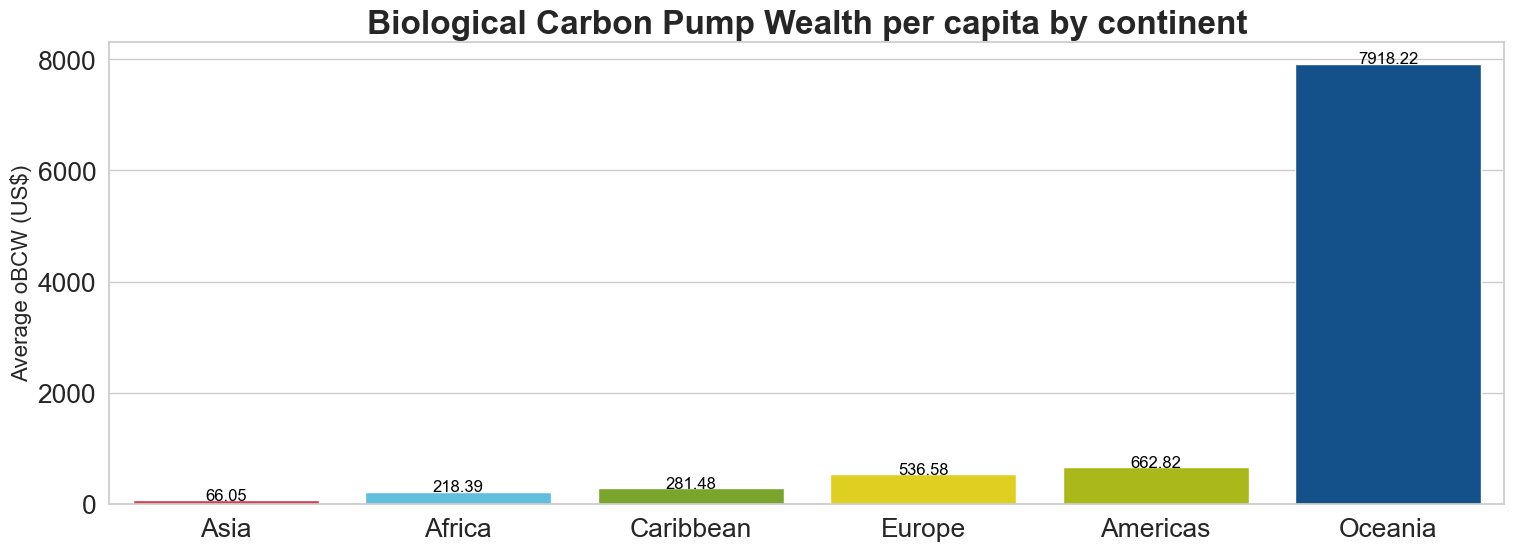

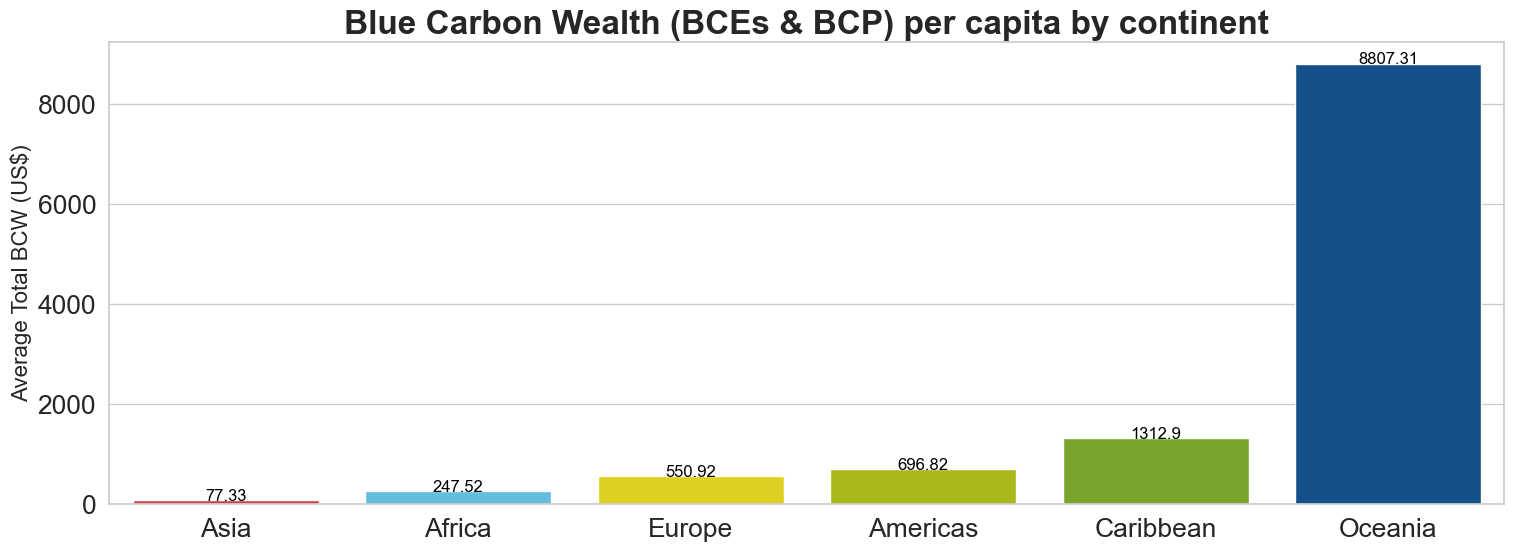

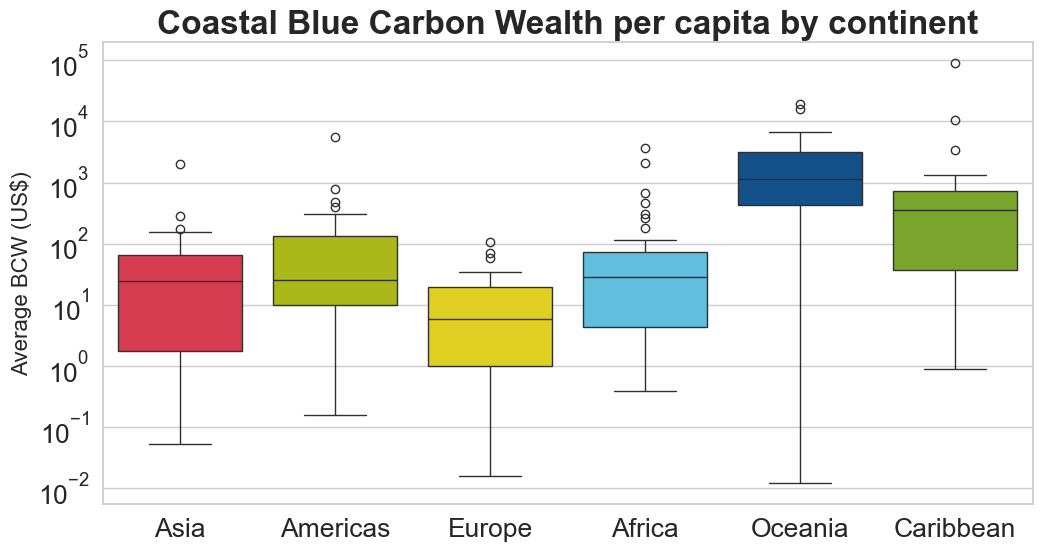

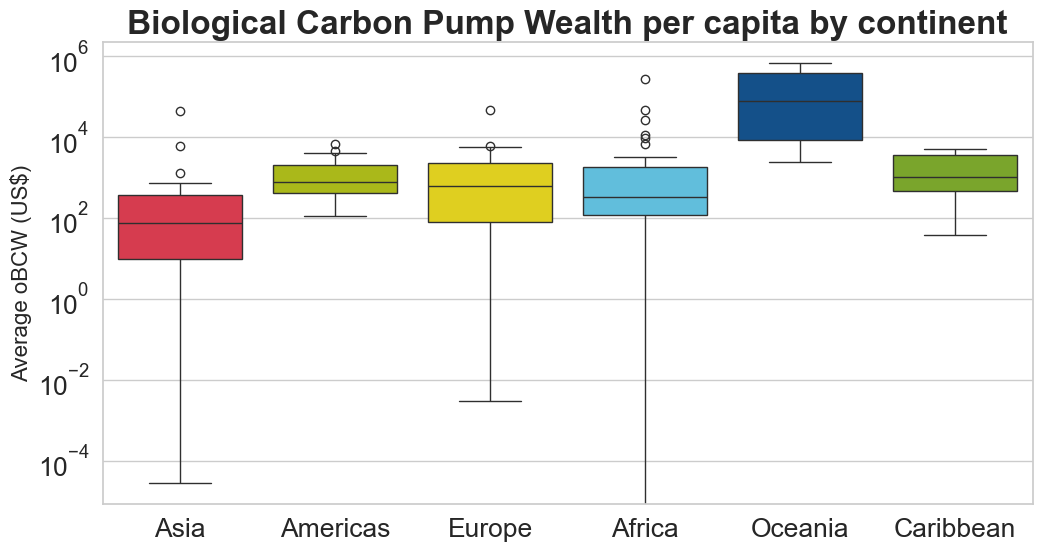

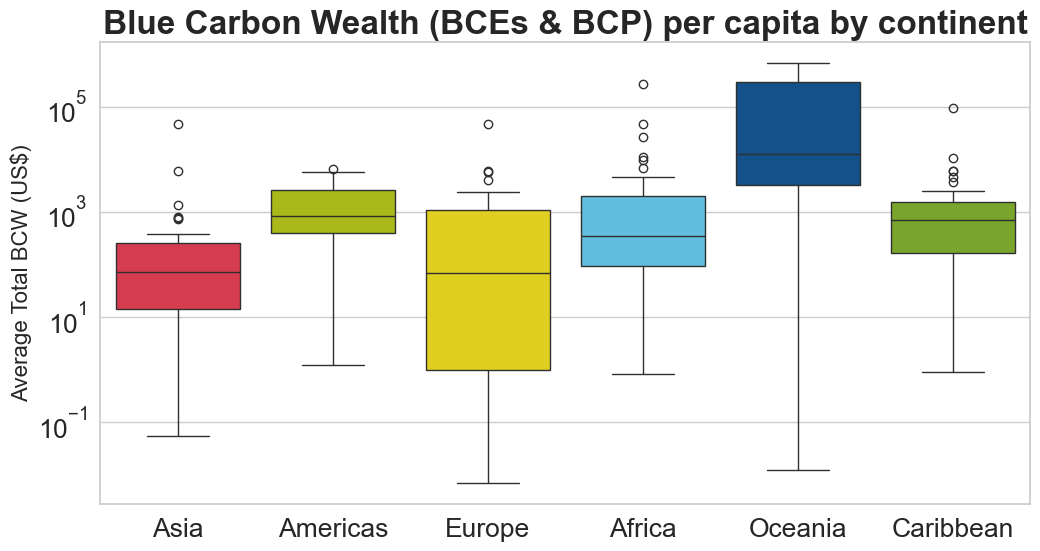

In [108]:
# supl5
varlist = ['cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']
titles = ['Coastal Blue Carbon Wealth per capita by continent',
          'Biological Carbon Pump Wealth per capita by continent',
          'Blue Carbon Wealth (BCEs & BCP) per capita by continent']
ylabels = ['Average BCW (US$)',
           'Average oBCW (US$)',
              'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    cdf = continent.copy()
    cdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(18, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(cdf, x='Continent', y=var, ci=False, palette=pal)
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.xlabel('')
    for i, v in enumerate(cdf[var]):
        plt.text(
            i, v + 3, str(round(v, 2)), 
            color='black', ha='center'
        )
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.ylabel(ylabel, fontsize=16)
    plt.show()
    
# boxplots
for var, title, ylabel in zip(varlist, titles, ylabels):
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    sns.boxplot(data=data, x='Continent', y=var, palette=pal)
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.xlabel('')
    plt.yscale('log')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.ylabel(ylabel, fontsize=16)
    plt.show()

In [33]:
groups = data.groupby('Groups')[['cBCW', 'oBCW', 'Total BCW', 'Population']].mean().reset_index()
groups['cBCW_per_capita'] = groups['cBCW'] / groups['Population']
groups['oBCW_per_capita'] = groups['oBCW'] / groups['Population']
groups['Total BCW_per_capita'] = groups['Total BCW'] / groups['Population']
groups['Groups'] = groups['Groups'].replace({'Developed economies': 'Developed', 'Developing economies': 'Developing'})
groups

,Groups,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Developed,"1,226,431,421.9956","32,145,150,449.5200","22,593,637,361.3549","23,191,126.3103",52.8837,"1,386.0970",974.2363
1,Developing,"1,388,108,792.2203","18,403,914,621.0222","14,445,628,070.0744","66,733,570.7470",20.8008,275.7820,216.4672
2,LDCs,"1,281,454,189.8095","6,709,146,225.0000","6,393,184,353.0476","30,915,051.7027",41.4508,217.0188,206.7984
3,SIDS,"1,302,541,125.9674","7,698,110,054.3061","6,411,483,608.5667","1,283,504.6667","1,014.8316","5,997.7266","4,995.2943"


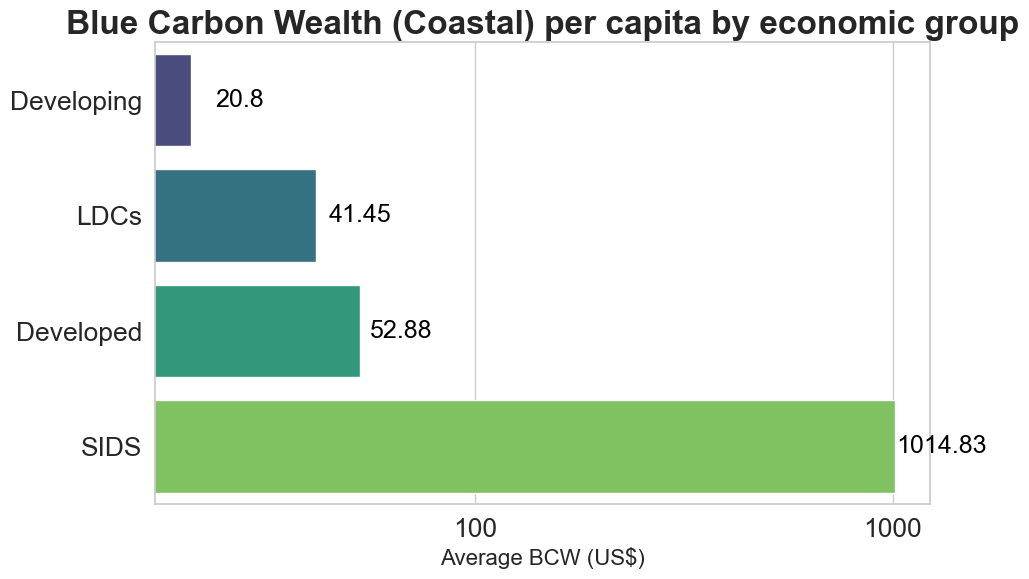

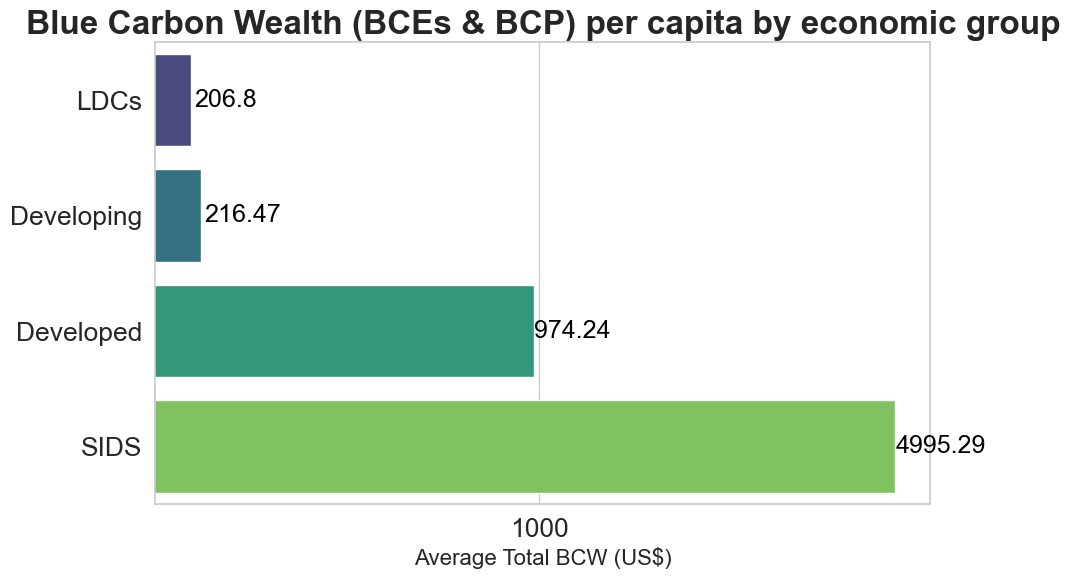

In [34]:
# supl5
# horizontal barplot for groups
varlist = ['cBCW_per_capita', 'Total BCW_per_capita']
titles = ['Blue Carbon Wealth (Coastal) per capita by economic group',
          'Blue Carbon Wealth (BCEs & BCP) per capita by economic group']
ylabels = ['Average BCW (US$)',
           'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    gdf = groups.copy()
    gdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(gdf, y='Groups', x=var, ci=False, palette='viridis')
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.ylabel('')
    for i, v in enumerate(gdf[var]):
        plt.text(
            v + 3, i, str(round(v, 2)), 
            color='black', va='center', fontsize=18
        )
    plt.xscale("log")
    format_log_axis_plain('x')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.xlabel(ylabel, fontsize=16)
    plt.show()

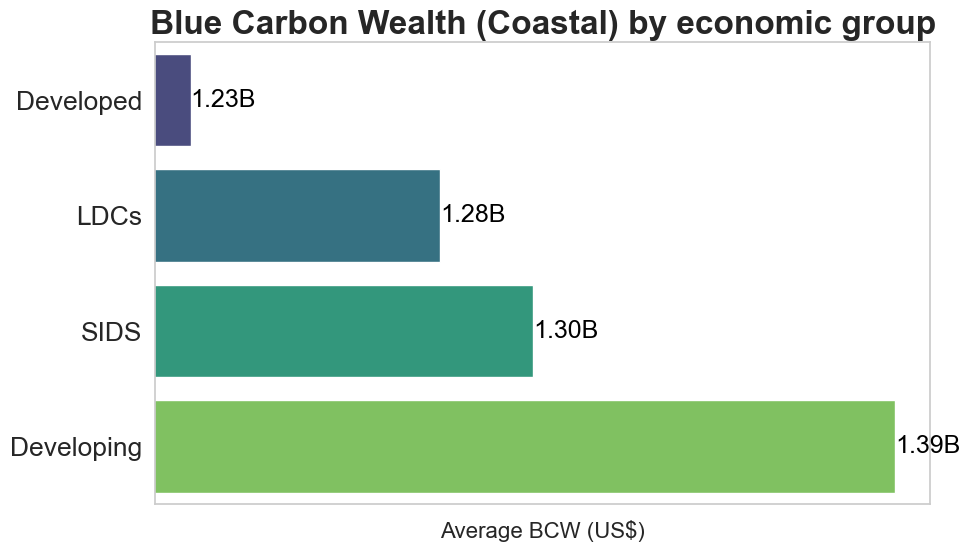

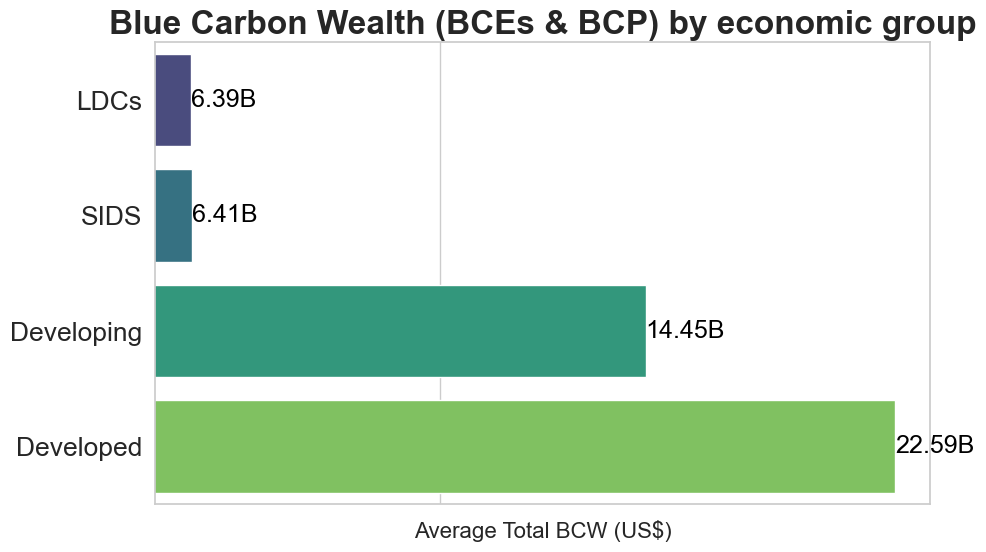

In [35]:
# supl5
# horizontal barplot for groups
varlist = ['cBCW', 'Total BCW']
titles = ['Blue Carbon Wealth (Coastal) by economic group',
          'Blue Carbon Wealth (BCEs & BCP) by economic group']
ylabels = ['Average BCW (US$)',
           'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    gdf = groups.copy()
    gdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(gdf, y='Groups', x=var, ci=False, palette='viridis')
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.ylabel('')
    for i, v in enumerate(gdf[var]):
        plt.text(
            v + 3, i, f'{v/1e9:.2f}B', 
            color='black', va='center', fontsize=18
        )
    plt.xticks(visible=False)
    plt.xscale("log")
    format_log_axis_plain('x')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.xlabel(ylabel, fontsize=16)
    plt.show()

In [36]:
dta = pd.read_csv(SUMMARY_DIR / 'bce_data.csv')
dta = dta.rename(columns={'country_name': 'entity', 'ISO_TER1': 'ISO'})
dta = dta[['entity', 'ISO', 'Area_EEZ_KM2', 'Continent']]
otj = dta[dta['entity'].str.contains('Joint regime|Overlapping', na=False)]
otj = otj.sort_values(by='entity').reset_index(drop=True)

for _, row in otj.iterrows():
    if 'Joint regime' in row['entity']:
        otj.loc[row.name, 'ISO'] = f'JR-{row.name + 1}'
    elif 'Overlapping claim' in row['entity']:
        otj.loc[row.name, 'ISO'] = f'OC-{row.name - 20}'
# 21 Joint regimes and 11 Overlapping claims
# Only one with data on Seq: Joint regime area Torres Strait Treaty: Papua New Guinea and Australia

full = pd.read_csv(DATA_DIR / 'shp' / 'EEZ_full.csv')
full = full[['UNION', 'ISO_TER1', 'ISO_TER2', 'ISO_TER3']]

otj_full = otj.merge(full, left_on='entity', right_on='UNION', how='left').drop(columns=['UNION'])

country_Total_BCW = data[['ISO', 'Total BCW_per_capita']].copy()
country_Total_BCW_unique = country_Total_BCW.drop_duplicates(subset='ISO')
otj_full['Total BCWpcap_1'] = otj_full['ISO_TER1'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])
otj_full['Total BCWpcap_2'] = otj_full['ISO_TER2'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])
otj_full['Total BCWpcap_3'] = otj_full['ISO_TER3'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])

otj_full['Total BCW_InvolvedStates'] = otj_full[['Total BCWpcap_1', 'Total BCWpcap_2', 'Total BCWpcap_3']].mean(axis=1).replace(0, np.nan)
otj_full.drop(columns=['Total BCWpcap_1', 'Total BCWpcap_2', 'Total BCWpcap_3', 'ISO_TER1', 'ISO_TER2', 'ISO_TER3'], inplace=True)

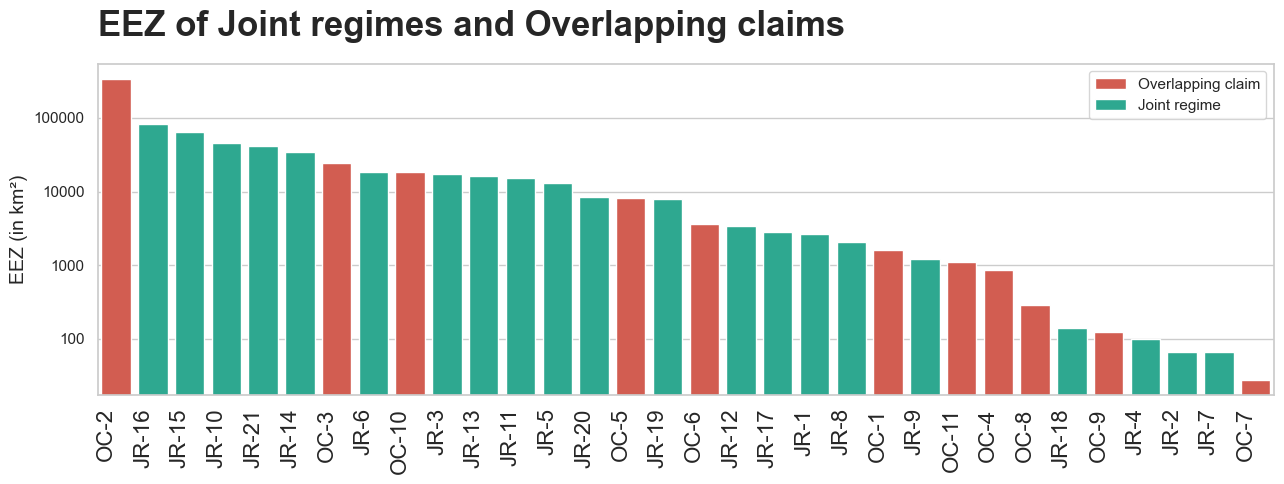

In [37]:
# supl8
plt.figure(figsize=(13, 5))
palette = {
    'Joint regime': '#1ABC9C',   # turquoise
    'Overlapping claim': '#E74C3C'  # corail chaud
}
otj_full['entity_type'] = otj_full['entity'].apply(lambda x: 'Joint regime' if 'Joint regime' in x else 'Overlapping claim')
sns.barplot(data=otj_full.sort_values(by='Area_EEZ_KM2', ascending=False), x='ISO', 
            y='Area_EEZ_KM2', hue='entity_type', palette=palette)

plt.xlabel('')
plt.xticks(rotation=90, ha='right', fontsize=16)
plt.ylabel('EEZ (in km²)', fontsize=14)
plt.yscale('log')
format_log_axis_plain('y')

plt.title('EEZ of Joint regimes and Overlapping claims', 
          fontsize=25, fontweight='bold', pad=20, loc='left')

plt.legend()
plt.tight_layout()
plt.show()

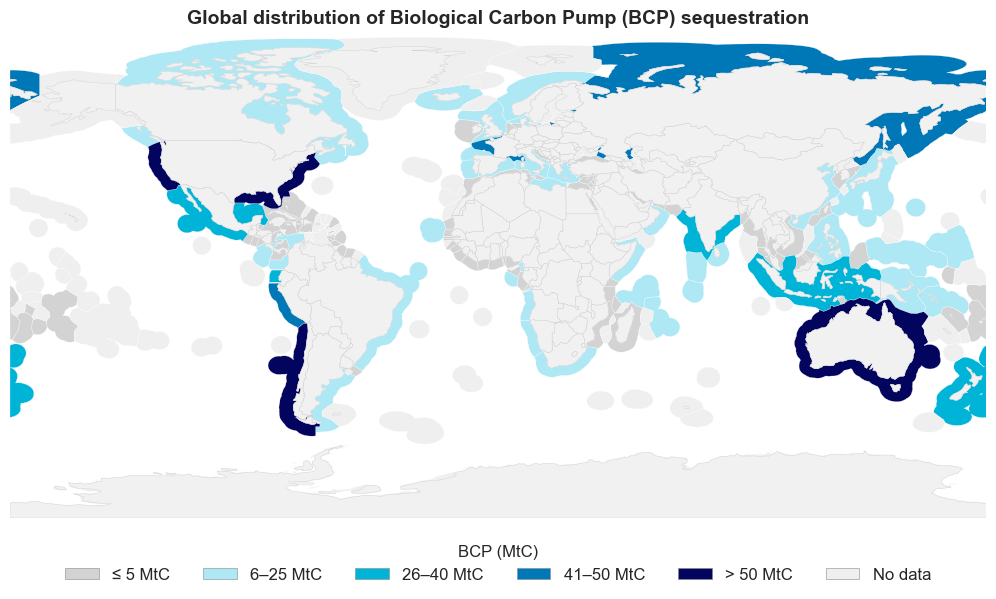

In [38]:
# supl11
# palet3 from color_map3
dbfm = plot_data.copy()
dbfm['Total BCEs Area (km²)'] = dbfm[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True).replace(0, np.nan)

palet3 = ListedColormap(list(color_map3.values()))

map_df = plot_data[
    ['country_name', 'BCP Seq (tC)']
].copy()
map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
map_df['BCP (MtC)'] = map_df['BCP Seq (tC)'] / 1e6  # convert to MtC

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=map_df,
    value_col='BCP (MtC)',
    merge_on='UNION',
    title='Global distribution of Biological Carbon Pump (BCP) sequestration',
    world_gdf=WLD_SHP,
    bins=[-1, 5, 25, 40, 50],
    units='MtC',
    palette=palet3,
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    legend_ncol=6,
    figsize=(14, 6),
    dissolve_by=None,
    clip_land=True,
)
plt.show()

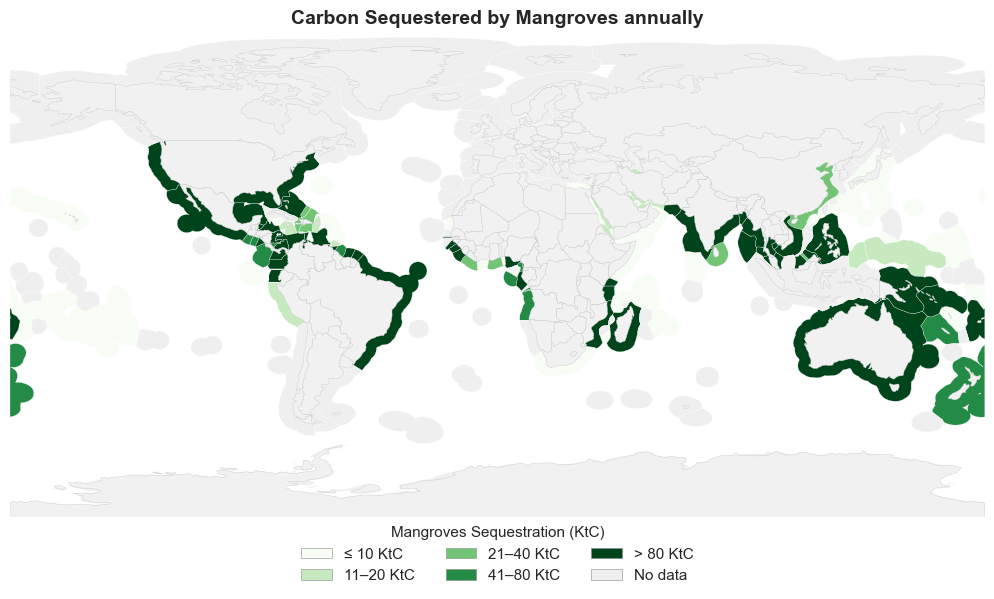

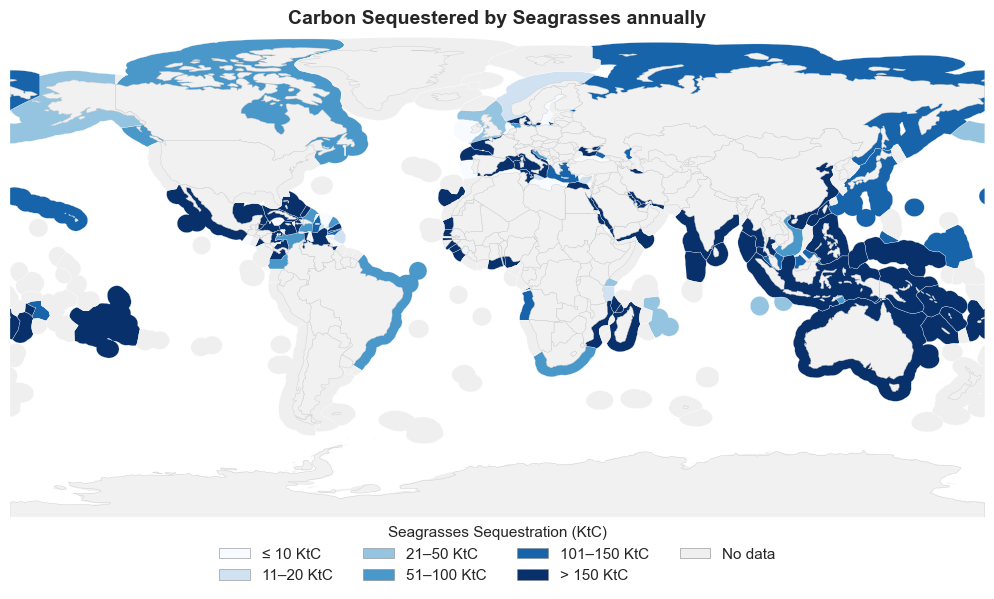

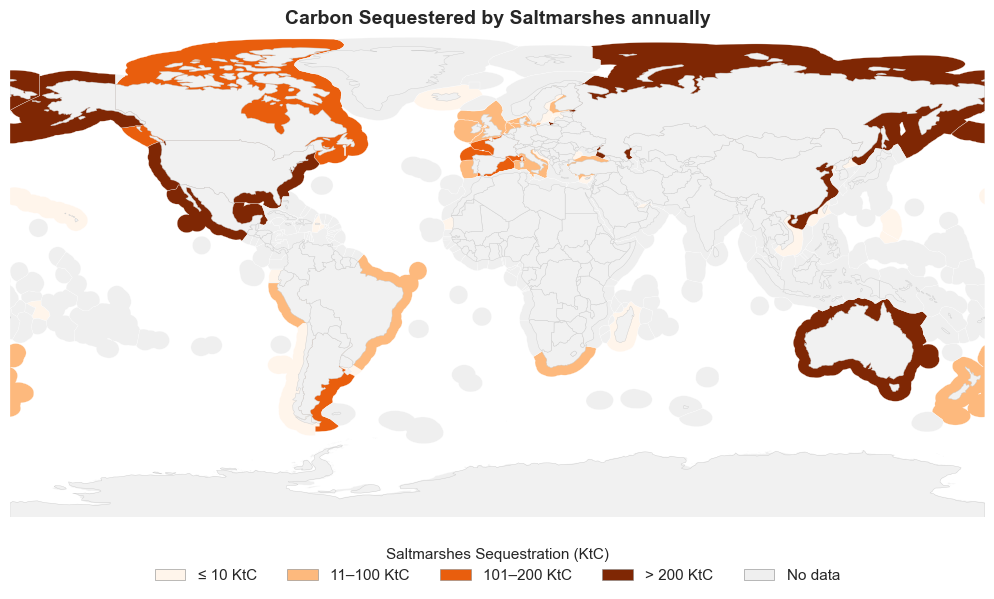

In [39]:
# supl11
dictvars = {
    'Mangroves': [
        'uptake_mang_mean', 'Greens', 'Carbon Sequestered by Mangroves annually',
        [-1, 10, 20, 40, 80], 3
    ],
    'Seagrasses': [
        'uptake_seag_mean', 'Blues', 'Carbon Sequestered by Seagrasses annually',
        [-1, 10, 20, 50, 100, 150], 4
    ],
    'Saltmarshes': [
        'uptake_salt_mean', 'Oranges', 'Carbon Sequestered by Saltmarshes annually',
        [-1, 10, 100, 200], 5
    ]
}

for ecosystem, (var, palet, title, bins, ncol) in dictvars.items():
    dbfm[f'{ecosystem} Sequestration (KtC)'] = dbfm[var]
    
    map_df = dbfm[['country_name', f'{ecosystem} Sequestration (KtC)']].copy()
    map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
    
    fig, ax, eez_disp = plot_eez_choropleth(
        eez_gdf=EEZ_SHP,
        data_df=map_df,
        value_col=f'{ecosystem} Sequestration (KtC)',
        merge_on='UNION',
        world_gdf=WLD_SHP,
        bins=bins,
        units='KtC',
        already_scaled=False,
        palette=palet,
        projection='EPSG:4326',
        missing_color='#efefef',
        title=title,
        legend_ncol=ncol
    )
    plt.show()

In [40]:
data['BCW_Debt_ratio'] = data['Total BCW'] / data['Debt (2015 US$)']
be = data[[
    'country_name', 'ISO', 'Groups', 'Continent', 'Population', 'cBCW', 'cBCW_per_capita', 
    'Total BCW', 'Total BCW_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita',
    'BCW_Debt_ratio'
]].copy()

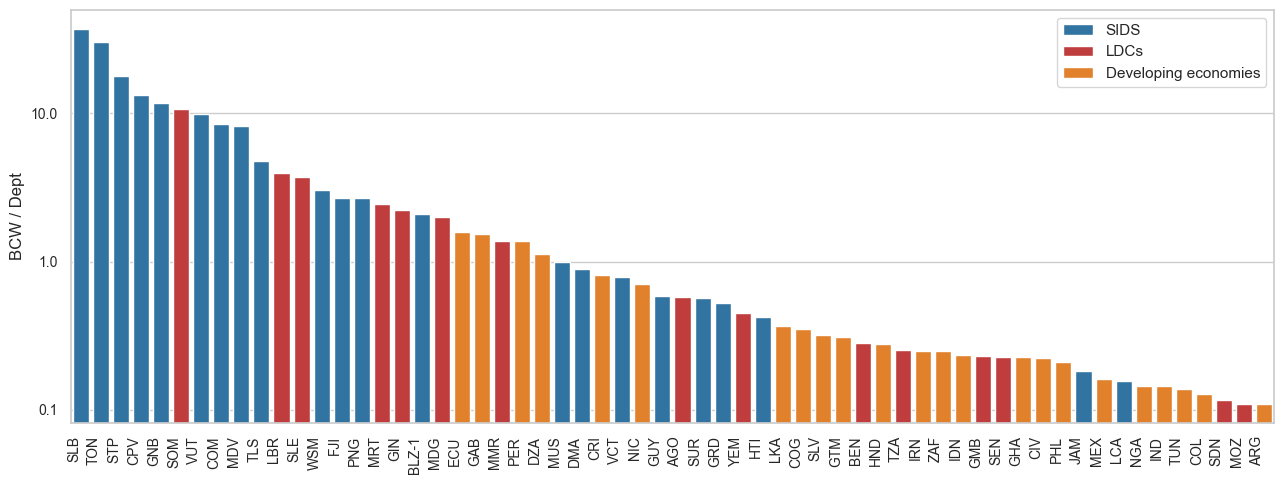

In [41]:
# supl22
by_bg = be[['ISO', 'Groups', 'BCW_Debt_ratio']].copy()
by_bg = be.sort_values(by='BCW_Debt_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:60, :], x='ISO', y='BCW_Debt_ratio', ci=False, palette= color_mapping, 
            hue='Groups',ax=ax)
plt.ylabel('BCW / Dept', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=90,ha='right')
plt.tick_params(axis='both', which='major', labelsize=10)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tight_layout()
plt.legend()
plt.show()

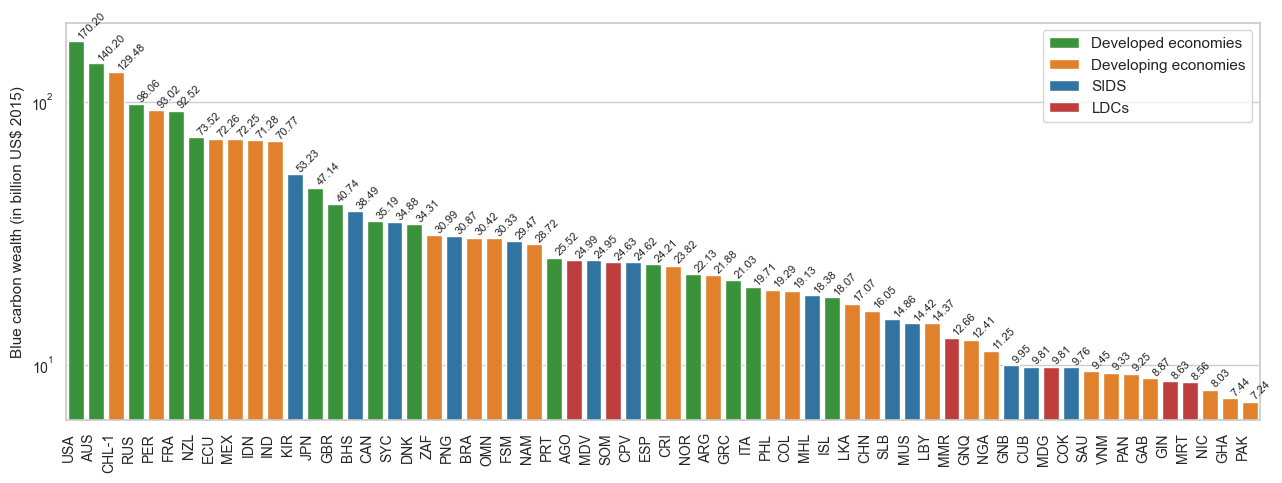

In [42]:
# supl22
# 2. Total BCW absolute value by country
by_countryx = data[['ISO', 'Total BCW', 'cBCW', 'Groups']].dropna(subset=['Groups']).sort_values(by='Total BCW', ascending=False)
by_countryx['Total BCW'] = by_countryx['Total BCW'] / 1e9
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=by_countryx.head(60), y='Total BCW', x='ISO', palette=color_mapping, hue='Groups', ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height:,.2f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth (in billion US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='right', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

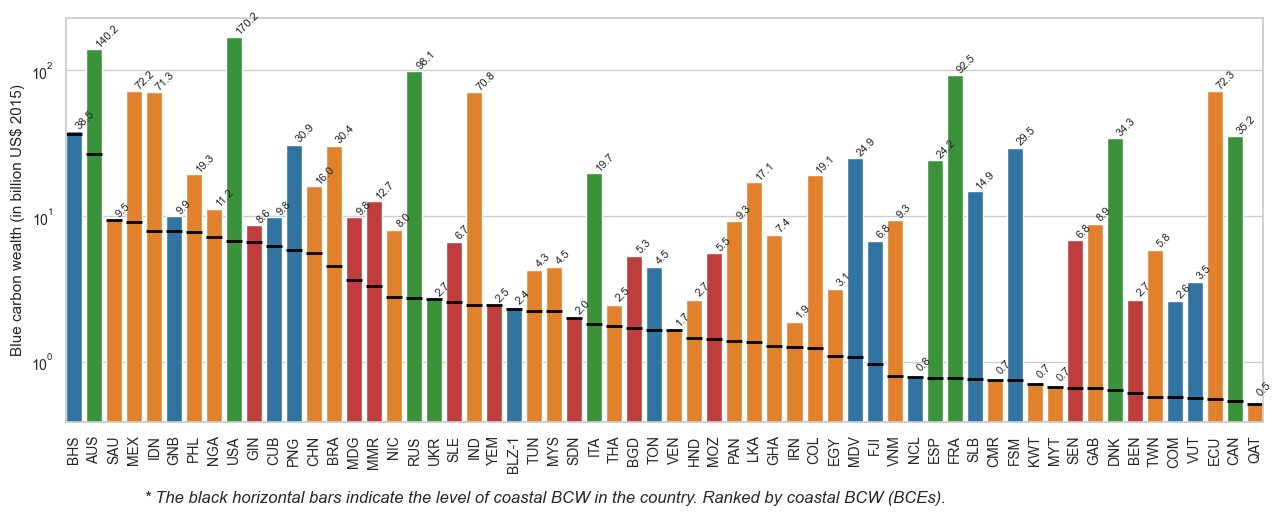

In [43]:
# supl22
# 2. Total BCW absolute value by country
by_country = data[['ISO', 'Total BCW', 'cBCW', 'Groups']].dropna(subset=['Groups']).sort_values(by='cBCW', ascending=False)
by_country['Total BCW'] = by_country['Total BCW']/1e9
by_country['cBCW'] = by_country['cBCW']/1e9
top = by_country.head(60)

fig, ax = plt.subplots(figsize=(13, 5))

# 1) Barres Total BCW
sns.barplot(
    data=top,
    y='Total BCW', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

for i, row in by_country.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW']) else row['cBCW']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height:,.1f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth (in billion US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend().remove()
plt.figtext(
    0.425, 0, 
    "* The black horizontal bars indicate the level of coastal BCW in the country. Ranked by coastal BCW (BCEs).",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

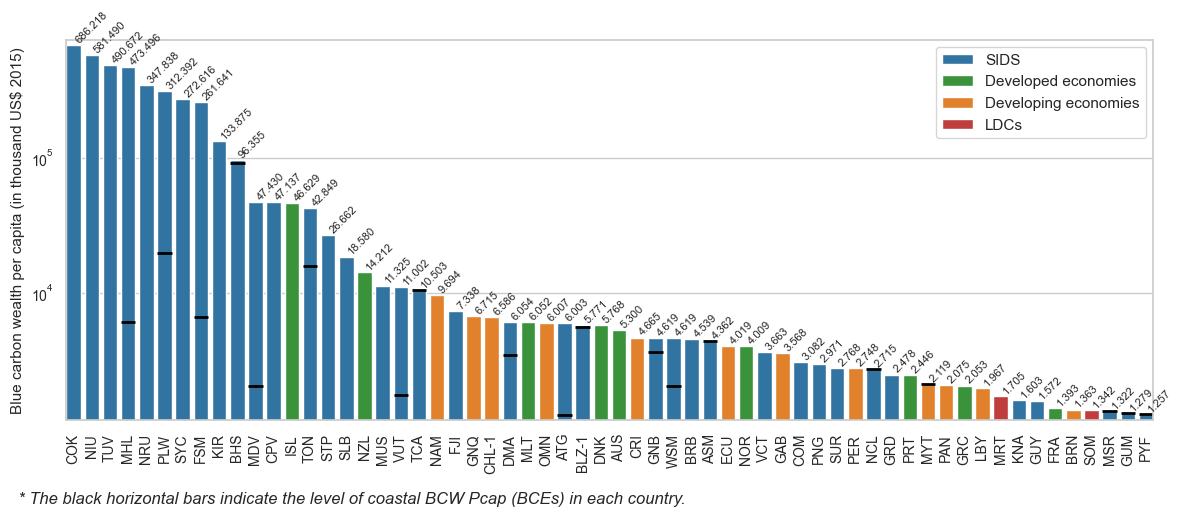

In [44]:
# supl22
# Total BCW_per_capita absolute value by country
by_country = data[['ISO', 'Total BCW_per_capita', 'cBCW_per_capita', 'Groups']].dropna(subset=['Groups']).sort_values(by='Total BCW_per_capita', ascending=False)
top = by_country.head(60)

fig, ax = plt.subplots(figsize=(12, 5))

# Bars for Total BCW_per_capita
sns.barplot(
    data=top,
    y='Total BCW_per_capita', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

ymin = top['Total BCW_per_capita'].replace(0, np.nan).min()          
ymax = top['Total BCW_per_capita'].max()
ax.set_yscale('log')
ax.set_ylim(ymin*0.9, ymax*1.1)                     
ax.autoscale(enable=False, axis='y')                 

for i, row in by_country.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW_per_capita']) else row['cBCW_per_capita']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,   
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth per capita (in thousand US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center')
# ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.figtext(
    0.3, 0, 
    "* The black horizontal bars indicate the level of coastal BCW Pcap (BCEs) in each country.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()